## Section A — Setup & Overview

### A1. Imports & Setup

In [1]:
# ── Imports ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size']  = 11

# ── Paths ─────────────────────────────────────────────
# NOTE: original path C:\FYP\IR\EDA\... no longer exists -- data
# moved to data/raw/ during repo scaffolding. Fixed so the notebook is
# actually runnable; flagged explicitly rather than silently changed.
DATA_PATH = r"C:\FYP\data\raw\Debernardi et al 2020 data.csv"
OUT_DIR   = r"C:\FYP\notebooks\tabular_eda_outputs\\"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Load ──────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)

# ── Diagnosis label map ───────────────────────────────
DIAG_MAP    = {1: 'Control', 2: 'Benign', 3: 'PDAC'}
DIAG_COLORS = {
    'Control': 'steelblue',
    'Benign' : 'gold',
    'PDAC'   : 'tomato'
}
df['diagnosis_label'] = df['diagnosis'].map(DIAG_MAP)

print("✅ Libraries loaded successfully")
print(f"   Dataset shape: {df.shape}")
print(f"   Output folder: {OUT_DIR}")

✅ Libraries loaded successfully
   Dataset shape: (590, 15)
   Output folder: C:\FYP\notebooks\tabular_eda_outputs\\


### A2. Dataset Overview

In [2]:
# ── Dataset overview ──────────────────────────────────
print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"\n  Name:    Debernardi et al. 2020")
print(f"  Source:  Kaggle / UCI Repository")
print(f"  Task:    Multi-class classification")
print(f"           Predict PDAC from urine biomarkers")
print(f"\n  Rows (patients):  {df.shape[0]}")
print(f"  Columns:          {df.shape[1]}")

print(f"\n{'─'*55}")
print("  COLUMN NAMES AND TYPES")
print(f"{'─'*55}")
print(df.dtypes.to_string())

print(f"\n{'─'*55}")
print("  FIRST 5 ROWS")
print(f"{'─'*55}")
print(df.head().to_string())

print(f"\n{'─'*55}")
print("  BASIC STATISTICS (numeric columns)")
print(f"{'─'*55}")
print(df.describe().round(3).to_string())

  DATASET OVERVIEW

  Name:    Debernardi et al. 2020
  Source:  Kaggle / UCI Repository
  Task:    Multi-class classification
           Predict PDAC from urine biomarkers

  Rows (patients):  590
  Columns:          15

───────────────────────────────────────────────────────
  COLUMN NAMES AND TYPES
───────────────────────────────────────────────────────
sample_id                      str
patient_cohort                 str
sample_origin                  str
age                          int64
sex                            str
diagnosis                    int64
stage                          str
benign_sample_diagnosis        str
plasma_CA19_9              float64
creatinine                 float64
LYVE1                      float64
REG1B                      float64
TFF1                       float64
REG1A                      float64
diagnosis_label                str

───────────────────────────────────────────────────────
  FIRST 5 ROWS
────────────────────────────────────────────

### A3. Helper Functions

Two patterns repeat across almost every section below: splitting a column's values into three arrays by diagnosis class, and computing missingness split by a grouping column. Pulled out once here instead of copy-pasting. Also imports `scipy.stats.kruskal` here — not a new project dependency, `scipy` is already in `requirements.txt`, just a new import in this notebook, needed for Section I2's non-parametric test (appropriate given Section F confirms these biomarkers are far from normally distributed, an assumption Pearson doesn't make but ANOVA would).

In [3]:
from scipy.stats import kruskal


def values_by_diagnosis(df, col, classes=('Control', 'Benign', 'PDAC')):
    """NaN-dropped values for one column, split into a list of arrays per
    diagnosis class -- the boxplot/histogram data pattern repeated across
    every distribution section in this notebook."""
    return [df.loc[df.diagnosis_label == cls, col].dropna().values for cls in classes]


def missing_count_by_group(df, col, group_col):
    """Missing count / total / missing% for one column, split by another
    column's groups (diagnosis, cohort, or sample origin)."""
    counts = df.groupby(group_col)[col].apply(lambda s: s.isnull().sum())
    totals = df.groupby(group_col).size()
    return pd.DataFrame({
        'missing': counts,
        'total': totals,
        'missing_pct': (counts / totals * 100).round(1),
    })


print("Helper functions defined: values_by_diagnosis, missing_count_by_group")

Helper functions defined: values_by_diagnosis, missing_count_by_group


## Section B — Initial Content Review (simple pass)

### B1. Unique Values Per Categorical Column

A first, simple look at each categorical column's actual values — no comparison against documented values yet (that's Section C). Just: what's actually in this column? Stored in `observed_categories` for reuse in Section C2, rather than recomputing `.unique()` a second time there.

In [4]:
categorical_cols = ['sex', 'patient_cohort', 'sample_origin',
                    'diagnosis', 'stage', 'benign_sample_diagnosis']
observed_categories = {}

print("=" * 55)
print("  UNIQUE VALUES PER CATEGORICAL COLUMN")
print("=" * 55)
for col in categorical_cols:
    observed_categories[col] = df[col].dropna().unique()
    print(f"\n  {col}:")
    print(f"    {sorted(observed_categories[col].tolist(), key=str)}")

  UNIQUE VALUES PER CATEGORICAL COLUMN

  sex:
    ['F', 'M']

  patient_cohort:
    ['Cohort1', 'Cohort2']

  sample_origin:
    ['BPTB', 'ESP', 'LIV', 'UCL']

  diagnosis:
    [1, 2, 3]

  stage:
    ['I', 'IA', 'IB', 'II', 'IIA', 'IIB', 'III', 'IV']

  benign_sample_diagnosis:
    ['Abdominal Pain ', 'Biliary Stricture (Secondary to Stent) ', 'Cholecystitis', 'Cholecystitis ', 'Cholecystitis (Chronic) ', 'Cholecystitis (Chronic) Cholelithiasis', 'Cholecystitis (Chronic) Cholesterolsis', 'Choledochal Cyst ', 'Choledocholiathiasis', 'Choledocholiathiasis ', 'Cholelithiasis with adenomyomatous hyperplasia ', 'Duodenal Stricture', 'Duodenitis', 'Gallbladder Porcelain', 'Gallbladder polyps ', 'Gallstones', 'Gallstones ', 'Gallstones - Incidental ', 'Gastritis ', 'Gastritis and Reflux ', 'Ill defined lesion in uncinate process', 'Ischaemic Common Bile Duct Stricture', 'Pancreatitis', 'Pancreatitis ', 'Pancreatitis (Abscess)', 'Pancreatitis (Acute)', 'Pancreatitis (Alcohol)', 'Pancreatitis

### B2.1. Value Counts — `sex`

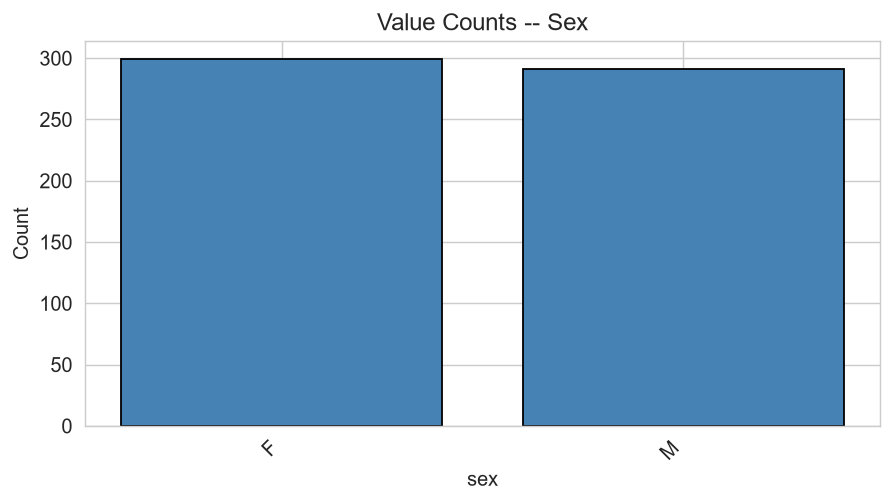

Saved: unique_counts_sex.png


In [5]:
plt.figure(figsize=(7, 4))
counts = df['sex'].value_counts(dropna=False)
plt.bar([str(x) for x in counts.index], counts.values, color='steelblue', edgecolor='black')
plt.title('Value Counts -- Sex')
plt.xlabel('sex')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR + 'unique_counts_sex.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: unique_counts_sex.png")

### B2.2. Value Counts — `patient_cohort`

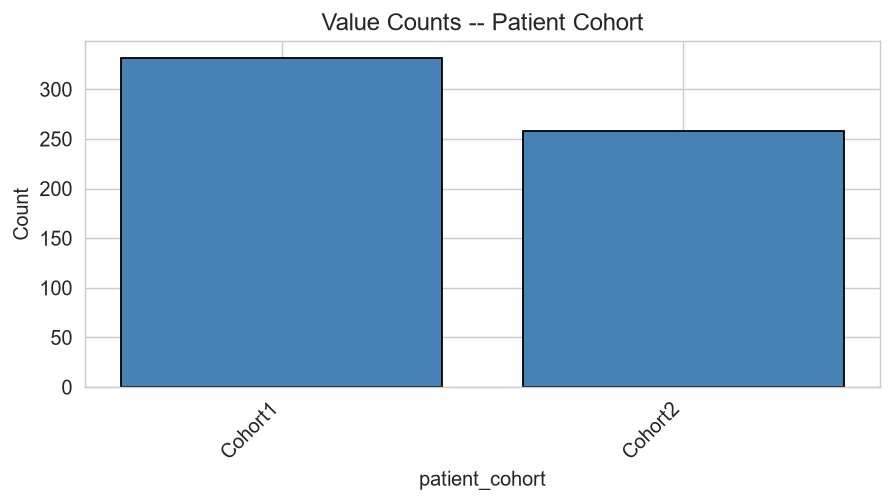

Saved: unique_counts_patient_cohort.png


In [6]:
plt.figure(figsize=(7, 4))
counts = df['patient_cohort'].value_counts(dropna=False)
plt.bar([str(x) for x in counts.index], counts.values, color='steelblue', edgecolor='black')
plt.title('Value Counts -- Patient Cohort')
plt.xlabel('patient_cohort')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR + 'unique_counts_patient_cohort.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: unique_counts_patient_cohort.png")

### B2.3. Value Counts — `sample_origin`

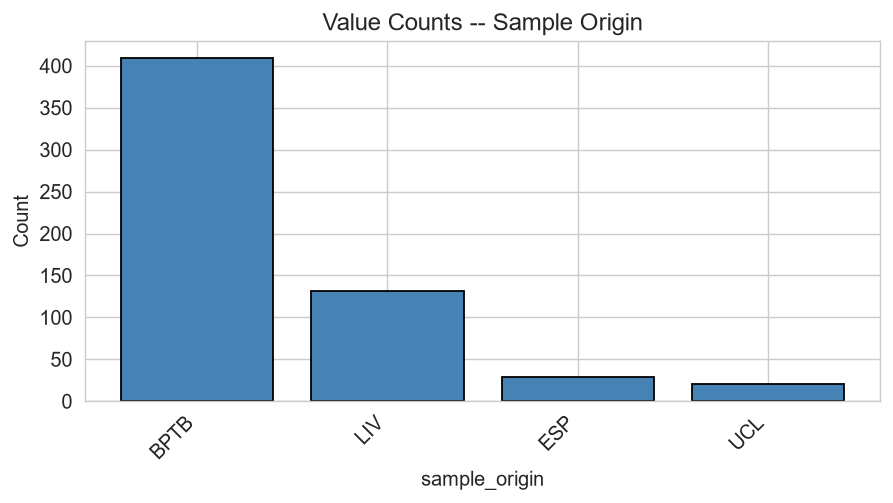

Saved: unique_counts_sample_origin.png


In [7]:
plt.figure(figsize=(7, 4))
counts = df['sample_origin'].value_counts(dropna=False)
plt.bar([str(x) for x in counts.index], counts.values, color='steelblue', edgecolor='black')
plt.title('Value Counts -- Sample Origin')
plt.xlabel('sample_origin')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR + 'unique_counts_sample_origin.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: unique_counts_sample_origin.png")

### B2.4. Value Counts — `diagnosis`

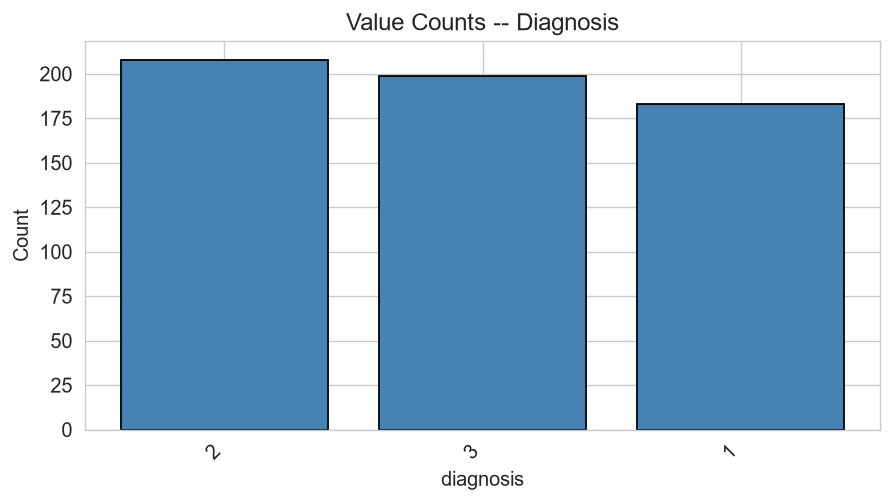

Saved: unique_counts_diagnosis.png


In [8]:
plt.figure(figsize=(7, 4))
counts = df['diagnosis'].value_counts(dropna=False)
plt.bar([str(x) for x in counts.index], counts.values, color='steelblue', edgecolor='black')
plt.title('Value Counts -- Diagnosis')
plt.xlabel('diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR + 'unique_counts_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: unique_counts_diagnosis.png")

### B2.5. Value Counts — `stage`

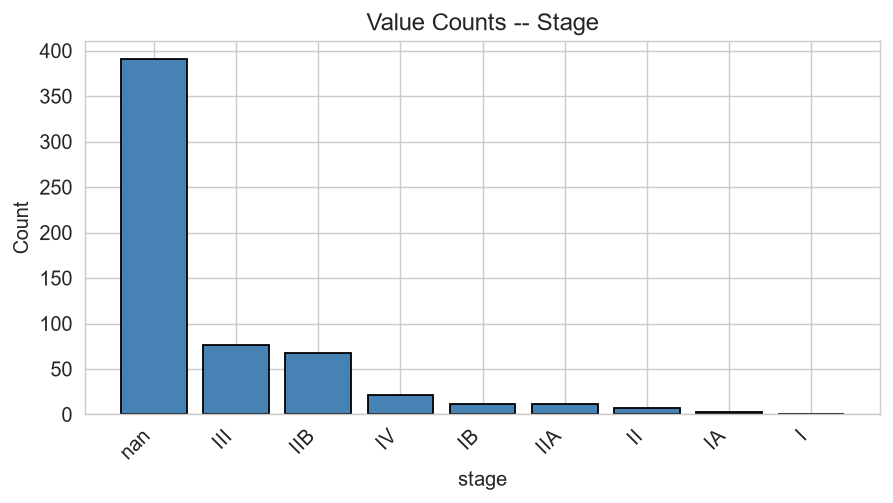

Saved: unique_counts_stage.png


In [9]:
plt.figure(figsize=(7, 4))
counts = df['stage'].value_counts(dropna=False)
plt.bar([str(x) for x in counts.index], counts.values, color='steelblue', edgecolor='black')
plt.title('Value Counts -- Stage')
plt.xlabel('stage')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR + 'unique_counts_stage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: unique_counts_stage.png")

### B2.6. Value Counts — `benign_sample_diagnosis`\n\n`benign_sample_diagnosis` has ~48 distinct free-text values -- shown in full rather than capped to top-N, since the density itself is the finding: this is genuinely heterogeneous free text, not a clean small vocabulary like the other categorical columns.

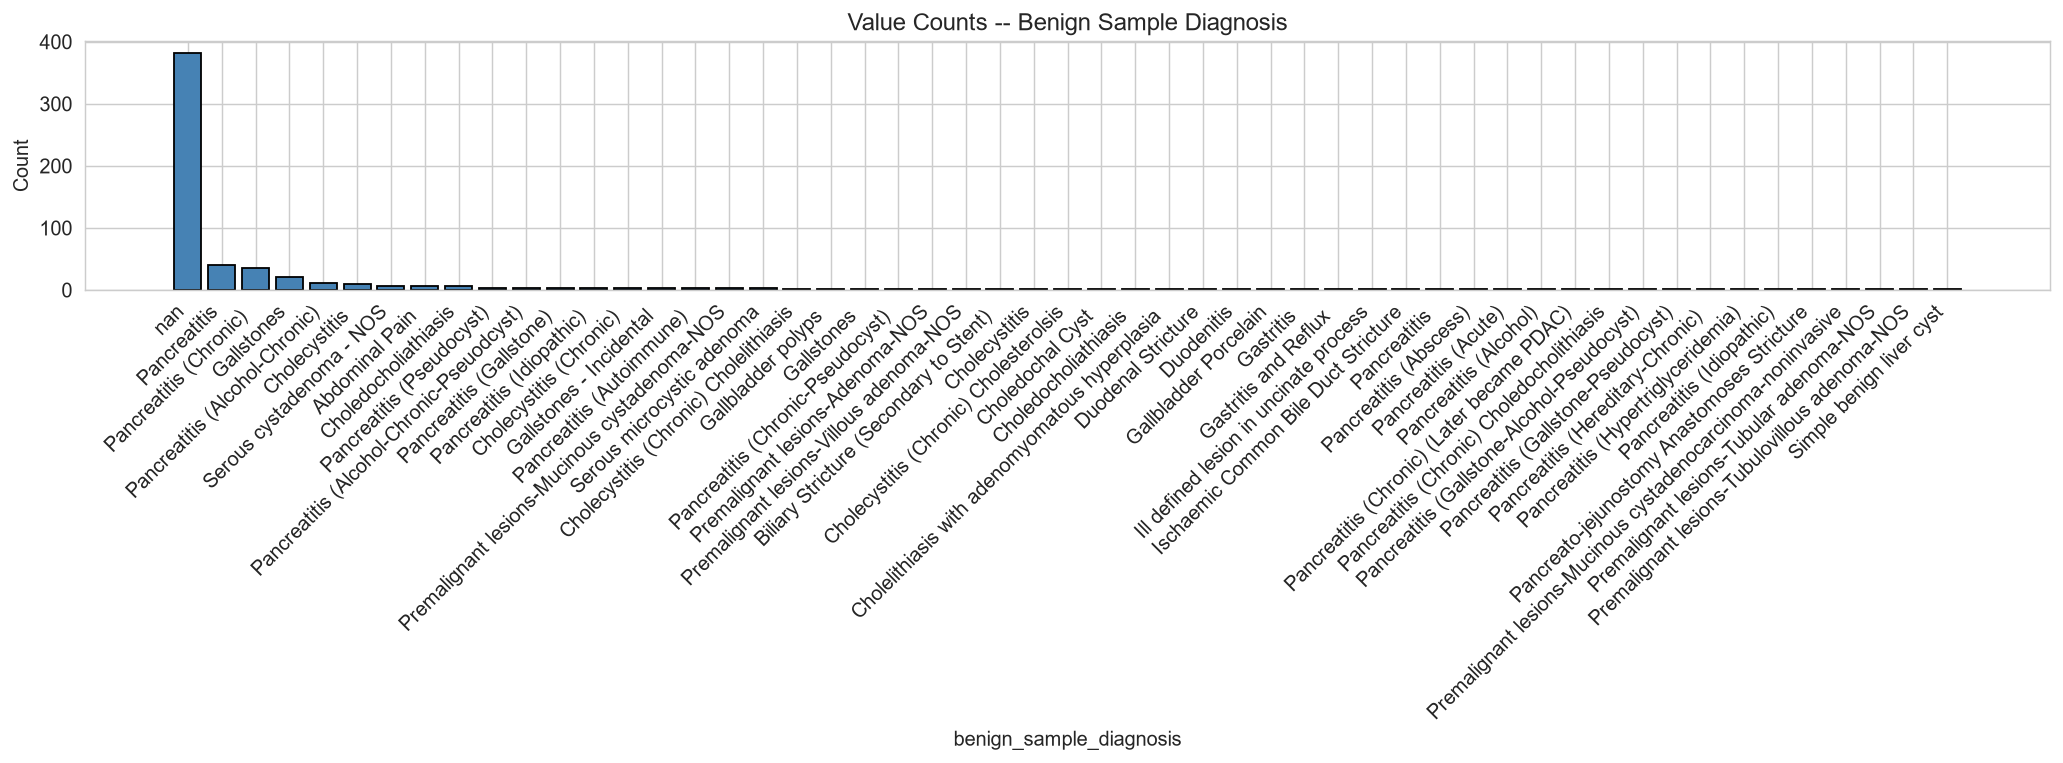

Saved: unique_counts_benign_sample_diagnosis.png


In [10]:
plt.figure(figsize=(16, 6))
counts = df['benign_sample_diagnosis'].value_counts(dropna=False)
plt.bar([str(x) for x in counts.index], counts.values, color='steelblue', edgecolor='black')
plt.title('Value Counts -- Benign Sample Diagnosis')
plt.xlabel('benign_sample_diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR + 'unique_counts_benign_sample_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: unique_counts_benign_sample_diagnosis.png")

## Section C — Data Quality & Integrity Checks (detailed pass)

### C1. Duplicate Patient ID Check

One row should mean one patient — check `sample_id` for duplicates before trusting any patient-level statistic downstream.

In [11]:
n_duplicate_ids = df['sample_id'].duplicated().sum()
print(f"Duplicate sample_id values: {n_duplicate_ids} "
      f"({'OK -- all unique' if n_duplicate_ids == 0 else 'INVESTIGATE'})")

Duplicate sample_id values: 0 (OK -- all unique)


### C2. Categorical Values vs. Data Dictionary

Compares Section B1's observed values against what `Debernardi et al 2020 documentation.csv` documents — flags anything found in the data but undocumented, and anything documented but never actually observed. The comparison sets below are transcribed directly from the dictionary's `Details` column, not parsed automatically — that column uses three different text conventions across rows (colon-separated, comma-separated, `=`-separated), inconsistent enough that a generic parser would be more fragile than citing the source text directly. `benign_sample_diagnosis` has no documented fixed vocabulary at all (the dictionary describes it as free text), so it's validated structurally instead — non-null exclusively for Benign patients.

In [12]:
data_dict = pd.read_csv(r"C:\FYP\data\raw\Debernardi et al 2020 documentation.csv")

DOCUMENTED_VALUES = {
    'patient_cohort': {'Cohort1', 'Cohort2'},        # dictionary: "Cohort 1 ... Cohort 2 ..."
    'sample_origin':  {'BPTB', 'ESP', 'LIV', 'UCL'},
    'sex':            {'M', 'F'},
    'diagnosis':      {1, 2, 3},
    'stage':          {'IA', 'IB', 'IIA', 'IIIB', 'III', 'IV'},  # dictionary: "One of IA, IB, IIA, IIIB, III, IV"
}

print("=" * 55)
print("  CATEGORICAL VALUES: OBSERVED (Section B1) vs DOCUMENTED")
print("=" * 55)
for col, documented in DOCUMENTED_VALUES.items():
    observed = set(observed_categories[col].tolist())
    undocumented_found = observed - documented
    documented_never_found = documented - observed
    print(f"\n  {col}:")
    print(f"    Observed:   {sorted(observed, key=str)}")
    print(f"    Documented: {sorted(documented, key=str)}")
    if undocumented_found:
        print(f"    \u26a0 Found but NOT documented: {sorted(undocumented_found, key=str)}")
    if documented_never_found:
        print(f"    \u26a0 Documented but NEVER found: {sorted(documented_never_found, key=str)}")
    if not undocumented_found and not documented_never_found:
        print(f"    \u2705 Exact match")

print(f"\n{'-' * 55}")
print("  benign_sample_diagnosis: no fixed vocabulary documented")
print(f"{'-' * 55}")
structural_check = pd.crosstab(df['diagnosis'], df['benign_sample_diagnosis'].notna())
print(structural_check.to_string())
is_exclusively_benign = (
    df.loc[df.diagnosis != 2, 'benign_sample_diagnosis'].isnull().all()
    and df.loc[df.diagnosis == 2, 'benign_sample_diagnosis'].notna().all()
)
print(f"  Non-null exclusively for Benign (diagnosis==2): {is_exclusively_benign}")

  CATEGORICAL VALUES: OBSERVED (Section B1) vs DOCUMENTED

  patient_cohort:
    Observed:   ['Cohort1', 'Cohort2']
    Documented: ['Cohort1', 'Cohort2']
    ✅ Exact match

  sample_origin:
    Observed:   ['BPTB', 'ESP', 'LIV', 'UCL']
    Documented: ['BPTB', 'ESP', 'LIV', 'UCL']
    ✅ Exact match

  sex:
    Observed:   ['F', 'M']
    Documented: ['F', 'M']
    ✅ Exact match

  diagnosis:
    Observed:   [1, 2, 3]
    Documented: [1, 2, 3]
    ✅ Exact match

  stage:
    Observed:   ['I', 'IA', 'IB', 'II', 'IIA', 'IIB', 'III', 'IV']
    Documented: ['IA', 'IB', 'IIA', 'III', 'IIIB', 'IV']
    ⚠ Found but NOT documented: ['I', 'II', 'IIB']
    ⚠ Documented but NEVER found: ['IIIB']

-------------------------------------------------------
  benign_sample_diagnosis: no fixed vocabulary documented
-------------------------------------------------------
benign_sample_diagnosis  False  True 
diagnosis                            
1                          183      0
2                     

### C3. Numeric Range Sanity Checks

Age within a broad plausibility bound (the dictionary gives no explicit bounds, so this checks against a generic 0-120 sanity range, not a documented clinical one), and every biomarker concentration is non-negative (a negative concentration isn't physically possible).

In [13]:
print(f"Age range: {df.age.min()}-{df.age.max()} years "
      f"(no documented bounds -- checked against a broad 0-120 plausibility bound)")
age_implausible = ((df.age < 0) | (df.age > 120)).sum()
print(f"  Implausible ages (outside 0-120): {age_implausible}")

biomarker_cols = ['plasma_CA19_9', 'creatinine', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']
print(f"\nBiomarker non-negativity (concentrations cannot be negative):")
for col in biomarker_cols:
    n_negative = (df[col] < 0).sum()
    print(f"  {col:15s}: min={df[col].min():.5f}  negative values={n_negative}")

Age range: 26-89 years (no documented bounds -- checked against a broad 0-120 plausibility bound)
  Implausible ages (outside 0-120): 0

Biomarker non-negativity (concentrations cannot be negative):
  plasma_CA19_9  : min=0.00000  negative values=0
  creatinine     : min=0.05655  negative values=0
  LYVE1          : min=0.00013  negative values=0
  REG1B          : min=0.00110  negative values=0
  TFF1           : min=0.00529  negative values=0
  REG1A          : min=0.00000  negative values=0


## Section D — Missing Value Analysis

### D1. Missing Count/% Per Column

  MISSING VALUES ANALYSIS
                         Missing Count  Missing %
stage                              391      66.27
benign_sample_diagnosis            382      64.75
REG1A                              284      48.14
plasma_CA19_9                      240      40.68

  Columns with NO missing: 11
  Columns WITH missing:    4


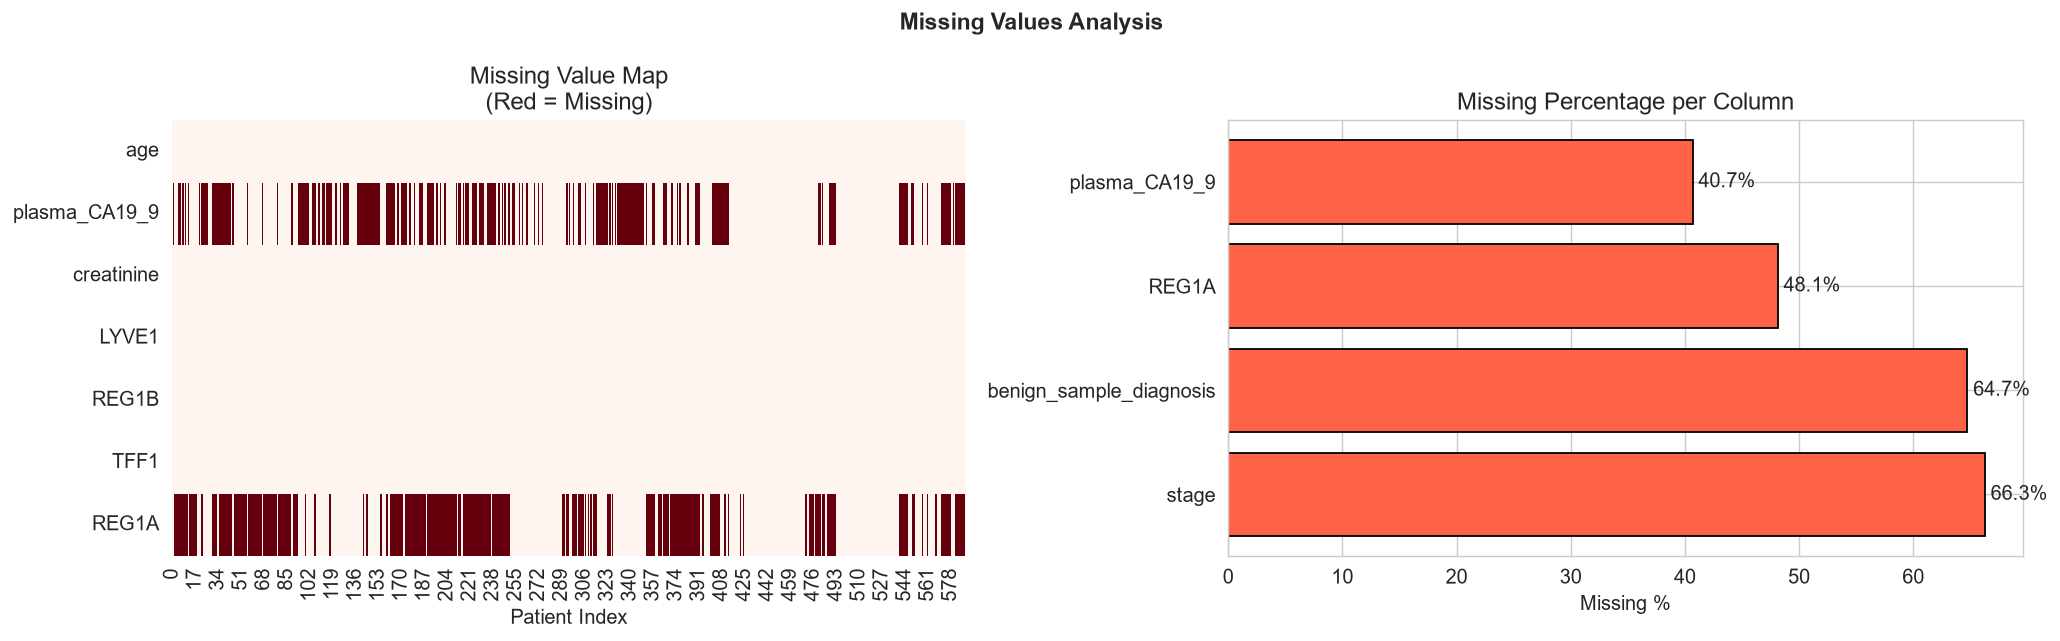

✅ Saved: missing_values.png


In [14]:
missing       = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df)) * 100
missing_df    = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print("=" * 55)
print("  MISSING VALUES ANALYSIS")
print("=" * 55)
print(missing_df[missing_df['Missing Count'] > 0].to_string())
print(f"\n  Columns with NO missing: {(missing == 0).sum()}")
print(f"  Columns WITH missing:    {(missing > 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Missing Values Analysis', fontsize=13, fontweight='bold')

numeric_cols = ['age', 'plasma_CA19_9', 'creatinine', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']
missing_matrix = df[numeric_cols].isnull()
sns.heatmap(missing_matrix.T, cbar=False, cmap='Reds', ax=axes[0], yticklabels=numeric_cols)
axes[0].set_title('Missing Value Map\n(Red = Missing)')
axes[0].set_xlabel('Patient Index')

missing_plot = missing_pct[missing_pct > 0].sort_values(ascending=False)
axes[1].barh(missing_plot.index, missing_plot.values, color='tomato', edgecolor='black')
axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Percentage per Column')
for i, v in enumerate(missing_plot.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.savefig(OUT_DIR + 'missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("\u2705 Saved: missing_values.png")

### D2. Structural Missingness: Explicit Sentinel Categories

`stage` and `benign_sample_diagnosis` missingness is **not a data defect** — it's structural. Section C2 confirmed 100% of `stage` nulls are non-PDAC patients (a Control/Benign patient has no cancer stage — there's nothing to impute) and 100% of `benign_sample_diagnosis` nulls are non-Benign patients. Because that null-exclusivity is already exact (verified, not assumed), a plain `.fillna()` on the whole column is equivalent to conditioning on diagnosis — no masking logic needed. This adds an explicit category rather than imputing a statistic, since "not applicable" isn't a value that can be estimated.

In [15]:
df['stage'] = df['stage'].fillna('No Cancer')
df['benign_sample_diagnosis'] = df['benign_sample_diagnosis'].fillna('Control/PDAC')

print("=" * 55)
print("  STRUCTURAL MISSINGNESS -- SENTINEL CATEGORIES ADDED")
print("=" * 55)
print(f"  stage value counts:\n{df['stage'].value_counts().to_string()}")
print(f"\n  benign_sample_diagnosis 'Control/PDAC' count: "
      f"{(df.benign_sample_diagnosis == 'Control/PDAC').sum()}")
print(f"\n  Remaining null stage: {df.stage.isnull().sum()}, "
      f"remaining null benign_sample_diagnosis: {df.benign_sample_diagnosis.isnull().sum()}")

  STRUCTURAL MISSINGNESS -- SENTINEL CATEGORIES ADDED
  stage value counts:
stage
No Cancer    391
III           76
IIB           68
IV            21
IB            12
IIA           11
II             7
IA             3
I              1

  benign_sample_diagnosis 'Control/PDAC' count: 382

  Remaining null stage: 0, remaining null benign_sample_diagnosis: 0


### D3. Missingness of plasma_CA19_9 / REG1A by Diagnosis Class

In [16]:
print("=" * 55)
print("  MISSING VALUES BY DIAGNOSIS CLASS")
print("=" * 55)
for col in ['plasma_CA19_9', 'REG1A']:
    print(f"\n  {col}:")
    miss_by_diag = df.groupby('diagnosis_label')[col].apply(lambda x: x.isnull().sum())
    total_by_diag = df.groupby('diagnosis_label').size()
    for cls in ['Control', 'Benign', 'PDAC']:
        pct = (miss_by_diag[cls] / total_by_diag[cls] * 100)
        print(f"    {cls:10s}: {miss_by_diag[cls]} missing ({pct:.1f}%)")

  MISSING VALUES BY DIAGNOSIS CLASS

  plasma_CA19_9:
    Control   : 91 missing (49.7%)
    Benign    : 100 missing (48.1%)
    PDAC      : 49 missing (24.6%)

  REG1A:
    Control   : 104 missing (56.8%)
    Benign    : 121 missing (58.2%)
    PDAC      : 59 missing (29.6%)


### D4. Missingness of plasma_CA19_9 / REG1A by Cohort and Sample Origin

Same missingness question as D3, two more groupings that reveal missing-BY-PROTOCOL rather than missing-by-diagnosis — e.g. a cohort or site that simply never ran an assay. This is where the sharpest finding lives: REG1A isn't just "assessed in fewer patients" in some spread-out sense, it's essentially absent from an entire cohort.

In [17]:
for group_col, group_label in [('patient_cohort', 'PATIENT COHORT'), ('sample_origin', 'SAMPLE ORIGIN')]:
    print(f"{'=' * 55}")
    print(f"  MISSING VALUES BY {group_label}")
    print(f"{'=' * 55}")
    for col in ['plasma_CA19_9', 'REG1A']:
        print(f"\n  {col}:")
        print(missing_count_by_group(df, col, group_col).to_string())
    print()

  MISSING VALUES BY PATIENT COHORT

  plasma_CA19_9:
                missing  total  missing_pct
patient_cohort                             
Cohort1             120    332         36.1
Cohort2             120    258         46.5

  REG1A:
                missing  total  missing_pct
patient_cohort                             
Cohort1              26    332          7.8
Cohort2             258    258        100.0

  MISSING VALUES BY SAMPLE ORIGIN

  plasma_CA19_9:
               missing  total  missing_pct
sample_origin                             
BPTB               176    409         43.0
ESP                 29     29        100.0
LIV                 15    132         11.4
UCL                 20     20        100.0

  REG1A:
               missing  total  missing_pct
sample_origin                             
BPTB               259    409         63.3
ESP                 19     29         65.5
LIV                  6    132          4.5
UCL                  0     20          0.0



## Section E — Class Distribution & Demographics

### E1. Target Class Distribution

  CLASS DISTRIBUTION
  Control     n= 183  (31.0%)
  Benign      n= 208  (35.3%)
  PDAC        n= 199  (33.7%)

  Total: 590 patients


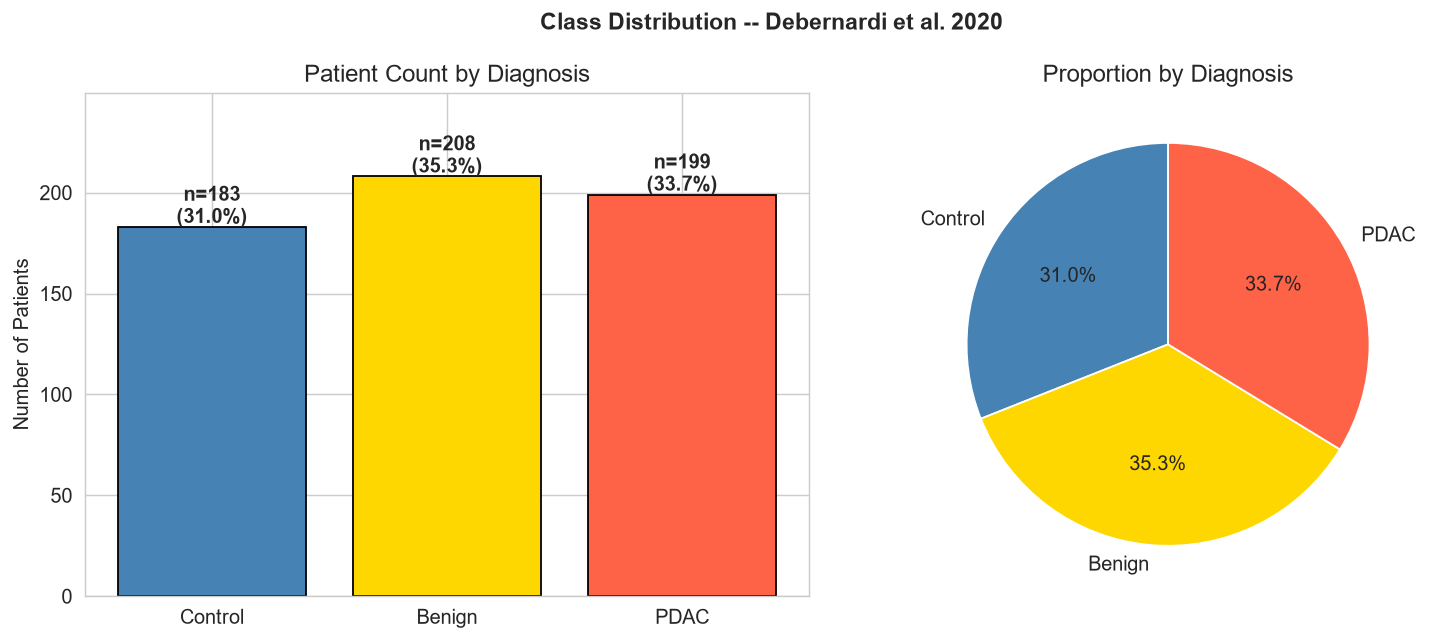

✅ Saved: class_distribution.png


In [18]:
counts = df['diagnosis_label'].value_counts()
pcts   = df['diagnosis_label'].value_counts(normalize=True) * 100

print("=" * 55)
print("  CLASS DISTRIBUTION")
print("=" * 55)
for cls in ['Control', 'Benign', 'PDAC']:
    print(f"  {cls:10s}  n={counts[cls]:4d}  ({pcts[cls]:.1f}%)")
print(f"\n  Total: {len(df)} patients")

order  = ['Control', 'Benign', 'PDAC']
colors = [DIAG_COLORS[c] for c in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Class Distribution -- Debernardi et al. 2020', fontsize=13, fontweight='bold')

axes[0].bar(order, [counts[c] for c in order], color=colors, edgecolor='black')
for i, cls in enumerate(order):
    axes[0].text(i, counts[cls] + 2, f"n={counts[cls]}\n({pcts[cls]:.1f}%)", ha='center', fontweight='bold')
axes[0].set_title('Patient Count by Diagnosis')
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, max(counts) * 1.2)

axes[1].pie([counts[c] for c in order], labels=order, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proportion by Diagnosis')

plt.tight_layout()
plt.savefig(OUT_DIR + 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\u2705 Saved: class_distribution.png")

### E2. Cohort & Sample Origin Crosstabs

  COHORT BREAKDOWN
diagnosis_label  Benign  Control  PDAC
patient_cohort                        
Cohort1              89       81   162
Cohort2             119      102    37

  SAMPLE ORIGIN BREAKDOWN
diagnosis_label  Benign  Control  PDAC
sample_origin                         
BPTB                143      183    83
ESP                   6        0    23
LIV                  39        0    93
UCL                  20        0     0


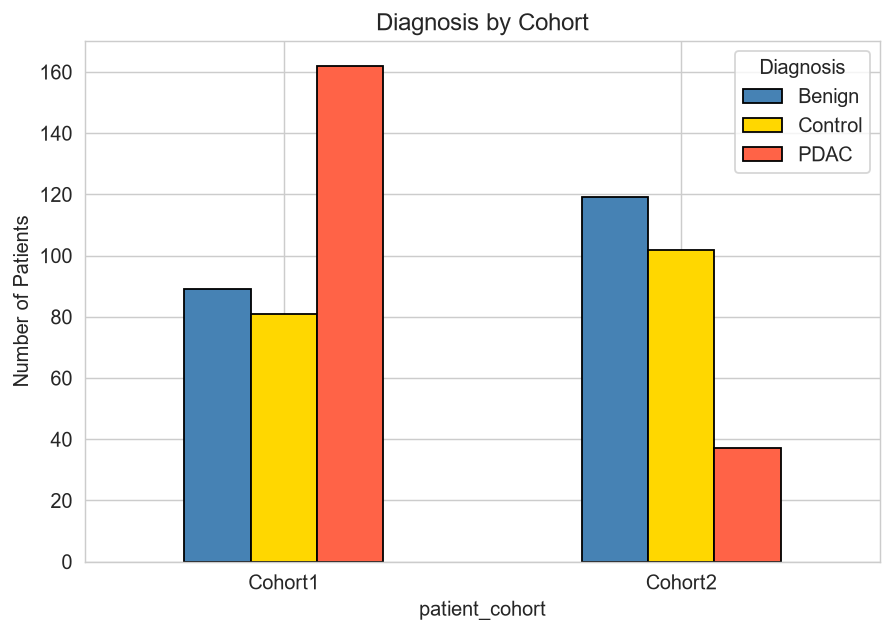

✅ Saved: class_distribution_by_cohort.png


In [19]:
cohort_diag = pd.crosstab(df['patient_cohort'], df['diagnosis_label'])
origin_diag = pd.crosstab(df['sample_origin'], df['diagnosis_label'])

print("=" * 55)
print("  COHORT BREAKDOWN")
print("=" * 55)
print(cohort_diag.to_string())

print(f"\n{'=' * 55}")
print("  SAMPLE ORIGIN BREAKDOWN")
print(f"{'=' * 55}")
print(origin_diag.to_string())

order  = ['Control', 'Benign', 'PDAC']
colors = [DIAG_COLORS[c] for c in order]

fig, ax = plt.subplots(figsize=(7, 5))
cohort_diag.plot(kind='bar', ax=ax, color=colors, edgecolor='black', rot=0)
ax.set_title('Diagnosis by Cohort')
ax.set_ylabel('Number of Patients')
ax.legend(title='Diagnosis')

plt.tight_layout()
plt.savefig(OUT_DIR + 'class_distribution_by_cohort.png', dpi=150, bbox_inches='tight')
plt.show()
print("\u2705 Saved: class_distribution_by_cohort.png")

### Cohort and sample-origin imbalance

Two findings already visible in the crosstabs printed above, worth calling out explicitly rather than leaving implicit in a table:

- **Cohort1 has a dramatically higher PDAC rate than Cohort2**: 162/332 (48.8%) of Cohort1 patients are PDAC, vs only 37/258 (14.3%) of Cohort2. Since `patient_cohort` distinguishes "previously used samples" (Cohort1) from "newly added samples" (Cohort2) per the data dictionary, this isn't necessarily a biological difference between cohorts — it may simply reflect how each batch of samples was originally collected/selected. Matters if ever splitting or stratifying by cohort: a naive split could easily concentrate PDAC cases in one partition.
- **UCL contributes only Benign cases**: all 20 UCL-origin samples are Benign (0 Control, 0 PDAC) — a representativeness gap, not a data error. Any model relying on `sample_origin` as a feature (or evaluated by origin) should treat UCL results cautiously, since there's no Control or PDAC signal from that site at all.

### E3. Age & Sex Demographics

  DEMOGRAPHIC ANALYSIS

  Age statistics by diagnosis:
                 count  mean   std   min   25%   50%   75%   max
diagnosis_label                                                 
Benign           208.0  54.7  13.3  26.0  44.0  54.0  66.0  82.0
Control          183.0  56.3  12.2  26.0  48.5  57.0  63.0  89.0
PDAC             199.0  66.2  10.5  29.0  59.0  67.0  74.0  88.0

───────────────────────────────────────────────────────
  Sex distribution by diagnosis:
sex                 F     M
diagnosis_label            
Benign           48.6  51.4
Control          62.8  37.2
PDAC             41.7  58.3


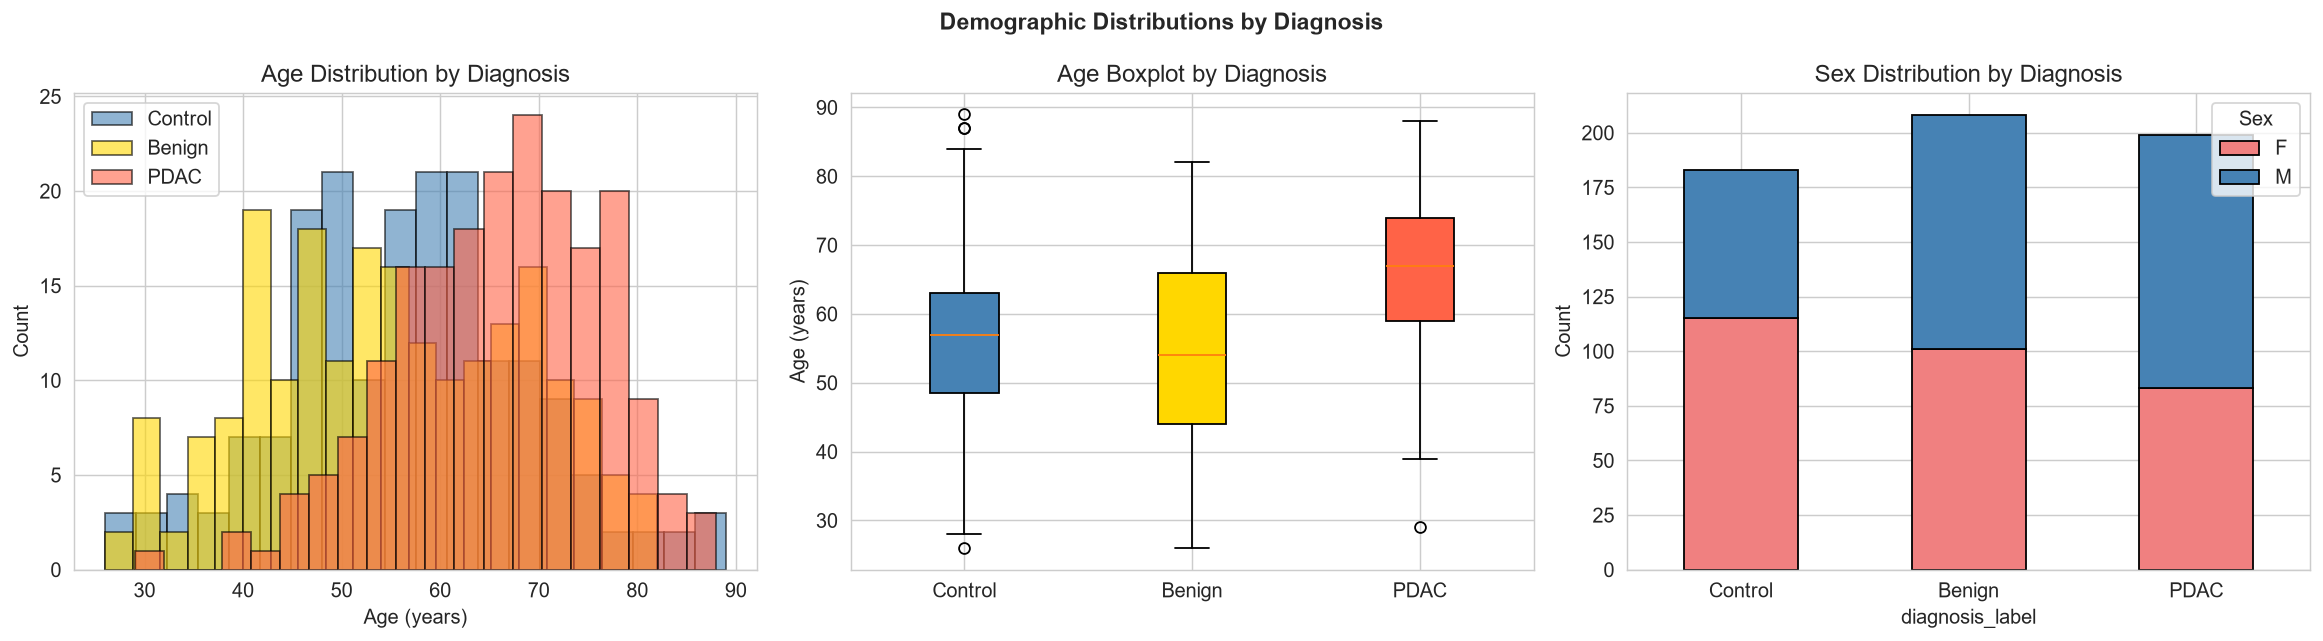

✅ Saved: demographics.png


In [20]:
# ── Age and sex analysis ──────────────────────────────
print("=" * 55)
print("  DEMOGRAPHIC ANALYSIS")
print("=" * 55)

# Age stats per class
print("\n  Age statistics by diagnosis:")
age_stats = df.groupby('diagnosis_label')[
    'age'
].describe().round(1)
print(age_stats.to_string())

# Sex distribution
print(f"\n{'─'*55}")
print("  Sex distribution by diagnosis:")
sex_diag = pd.crosstab(
    df['diagnosis_label'],
    df['sex'],
    normalize='index'
) * 100
print(sex_diag.round(1).to_string())

# ── Plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Demographic Distributions by Diagnosis',
    fontsize=13, fontweight='bold'
)

# Age histogram per class
for cls in ['Control', 'Benign', 'PDAC']:
    subset = df[df['diagnosis_label'] == cls]['age']
    axes[0].hist(
        subset,
        bins=20,
        alpha=0.6,
        label=cls,
        color=DIAG_COLORS[cls],
        edgecolor='black'
    )
axes[0].set_title('Age Distribution by Diagnosis')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Age boxplot
bp_data = [
    df[df['diagnosis_label'] == cls]['age'].values
    for cls in ['Control', 'Benign', 'PDAC']
]
bp = axes[1].boxplot(
    bp_data,
    patch_artist=True,
    tick_labels=['Control', 'Benign', 'PDAC']
)
for patch, cls in zip(
    bp['boxes'],
    ['Control', 'Benign', 'PDAC']
):
    patch.set_facecolor(DIAG_COLORS[cls])
axes[1].set_title('Age Boxplot by Diagnosis')
axes[1].set_ylabel('Age (years)')

# Sex stacked bar
sex_counts = pd.crosstab(
    df['diagnosis_label'], df['sex']
)
sex_counts.loc[['Control', 'Benign', 'PDAC']].plot(
    kind='bar',
    stacked=True,
    ax=axes[2],
    color=['lightcoral', 'steelblue'],
    edgecolor='black',
    rot=0
)
axes[2].set_title('Sex Distribution by Diagnosis')
axes[2].set_ylabel('Count')
axes[2].legend(title='Sex')

plt.tight_layout()
plt.savefig(
    OUT_DIR + 'demographics.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Saved: demographics.png")

## Section F — Distribution Shape (Skewness) — NO TRANSFORM APPLIED

**These biomarkers are lab test results — outliers and skew are expected real biology, not data errors.** This section shows and quantifies distribution shape; it does not log-transform, winsorize, or remove anything. Any log1p view from earlier notebook versions is removed here, not extended — raw values only.

### F1. Skewness — All Biomarkers

The original notebook only computed `.skew()` for LYVE1/REG1B/TFF1/REG1A — never for `plasma_CA19_9` or `creatinine` — despite the IR's headline claim that skewness reaches 10.37 in `plasma_CA19_9`. That claim doesn't match what this notebook actually computes (8.02, confirmed below). All six biomarkers, one consolidated table, NaNs dropped per column.

In [21]:
biomarker_cols = ['creatinine', 'LYVE1', 'REG1B', 'TFF1', 'REG1A', 'plasma_CA19_9']
skew_table = pd.DataFrame({
    'skewness': [df[col].dropna().skew() for col in biomarker_cols],
}, index=biomarker_cols).round(2)
skew_table['interpretation'] = skew_table.skewness.apply(
    lambda s: 'highly skewed (|skew|>1)' if abs(s) > 1
    else 'moderately skewed' if abs(s) > 0.5
    else 'roughly symmetric'
)

print("=" * 55)
print("  SKEWNESS -- ALL BIOMARKERS (NaNs dropped)")
print("=" * 55)
print(skew_table.to_string())

  SKEWNESS -- ALL BIOMARKERS (NaNs dropped)
               skewness            interpretation
creatinine         1.47  highly skewed (|skew|>1)
LYVE1              1.39  highly skewed (|skew|>1)
REG1B              3.33  highly skewed (|skew|>1)
TFF1               5.16  highly skewed (|skew|>1)
REG1A              4.47  highly skewed (|skew|>1)
plasma_CA19_9      8.02  highly skewed (|skew|>1)


### F2.1. Raw Histogram — `creatinine`

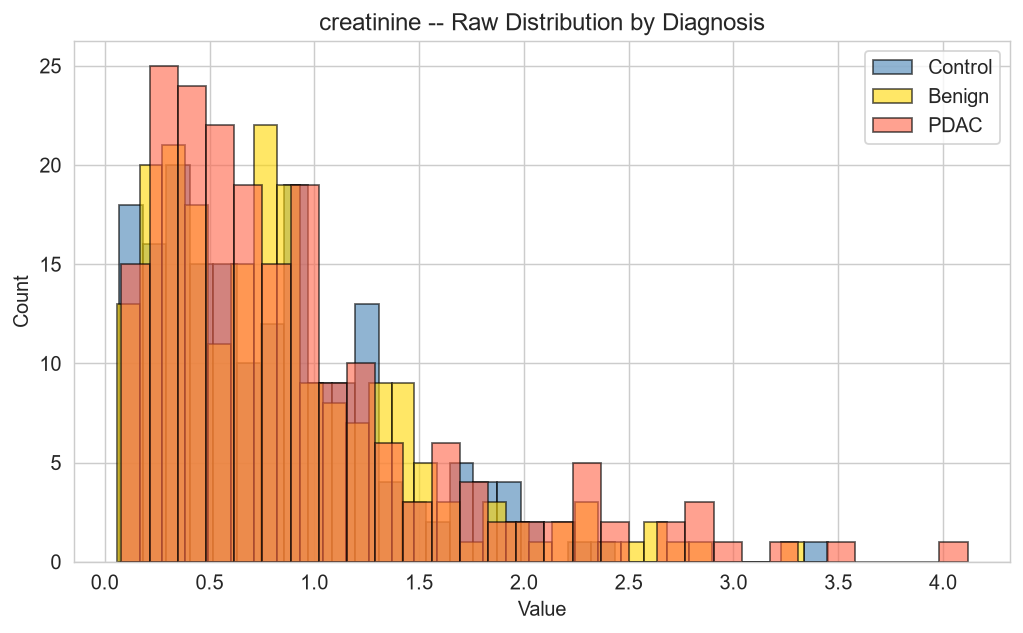

Saved: hist_raw_creatinine.png


In [22]:
plt.figure(figsize=(8, 5))
for cls, subset in zip(['Control', 'Benign', 'PDAC'], values_by_diagnosis(df, 'creatinine')):
    plt.hist(subset, bins=30, alpha=0.6, label=cls, color=DIAG_COLORS[cls], edgecolor='black')
plt.title('creatinine -- Raw Distribution by Diagnosis')
plt.xlabel('Value')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'hist_raw_creatinine.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hist_raw_creatinine.png")

### F2.2. Raw Histogram — `LYVE1`

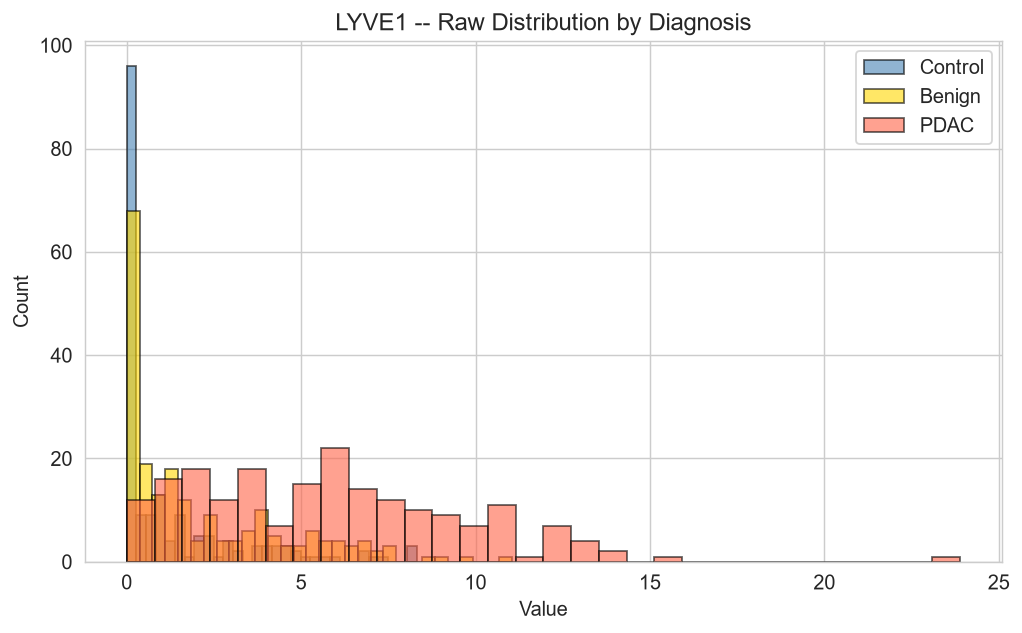

Saved: hist_raw_LYVE1.png


In [23]:
plt.figure(figsize=(8, 5))
for cls, subset in zip(['Control', 'Benign', 'PDAC'], values_by_diagnosis(df, 'LYVE1')):
    plt.hist(subset, bins=30, alpha=0.6, label=cls, color=DIAG_COLORS[cls], edgecolor='black')
plt.title('LYVE1 -- Raw Distribution by Diagnosis')
plt.xlabel('Value')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'hist_raw_LYVE1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hist_raw_LYVE1.png")

### F2.3. Raw Histogram — `REG1B`

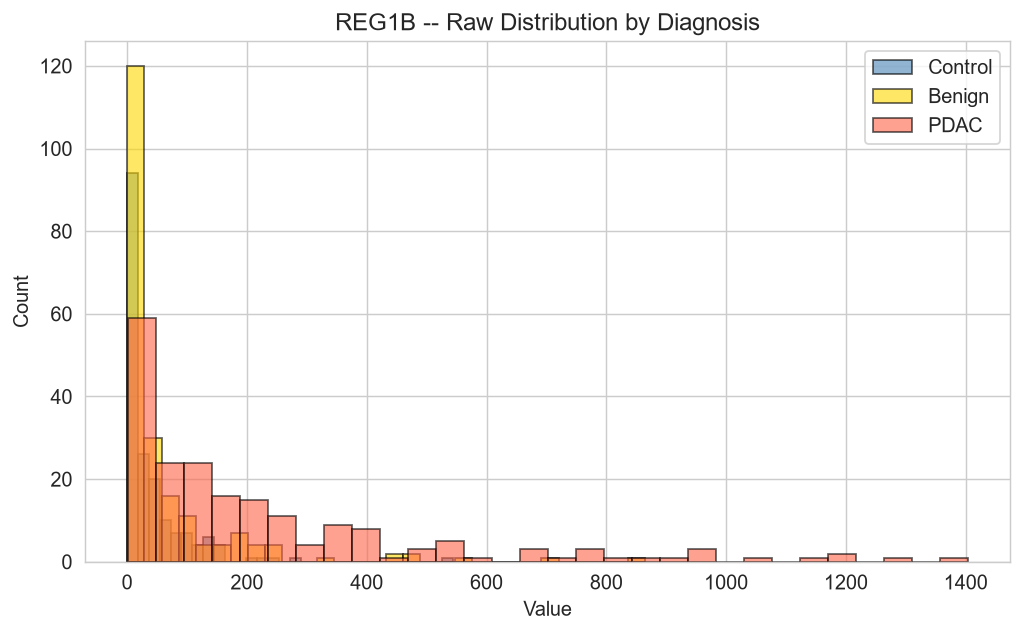

Saved: hist_raw_REG1B.png


In [24]:
plt.figure(figsize=(8, 5))
for cls, subset in zip(['Control', 'Benign', 'PDAC'], values_by_diagnosis(df, 'REG1B')):
    plt.hist(subset, bins=30, alpha=0.6, label=cls, color=DIAG_COLORS[cls], edgecolor='black')
plt.title('REG1B -- Raw Distribution by Diagnosis')
plt.xlabel('Value')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'hist_raw_REG1B.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hist_raw_REG1B.png")

### F2.4. Raw Histogram — `TFF1`

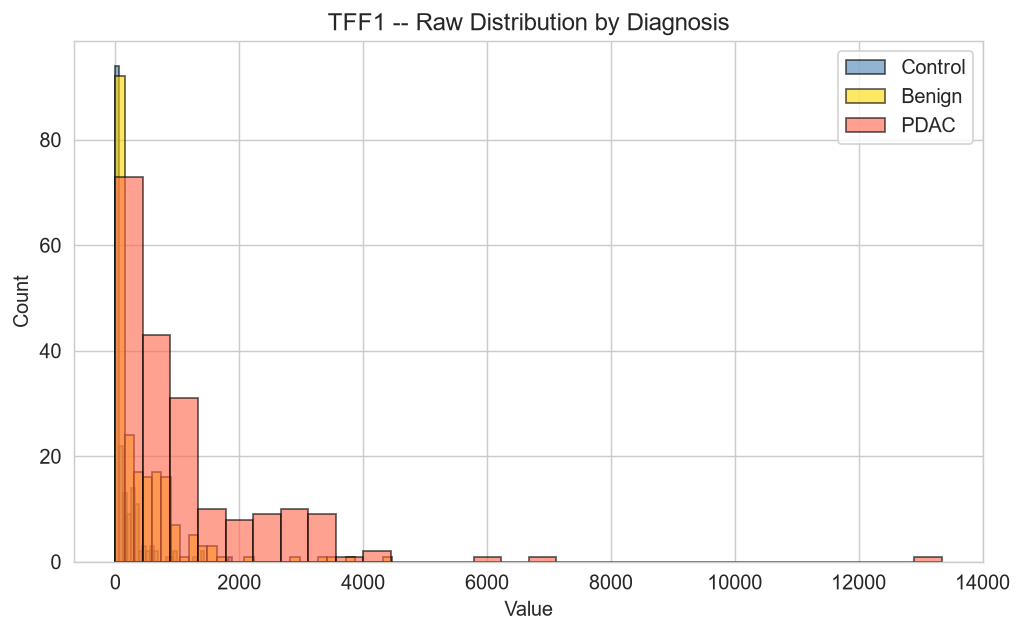

Saved: hist_raw_TFF1.png


In [25]:
plt.figure(figsize=(8, 5))
for cls, subset in zip(['Control', 'Benign', 'PDAC'], values_by_diagnosis(df, 'TFF1')):
    plt.hist(subset, bins=30, alpha=0.6, label=cls, color=DIAG_COLORS[cls], edgecolor='black')
plt.title('TFF1 -- Raw Distribution by Diagnosis')
plt.xlabel('Value')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'hist_raw_TFF1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hist_raw_TFF1.png")

### F2.5. Raw Histogram — `REG1A`

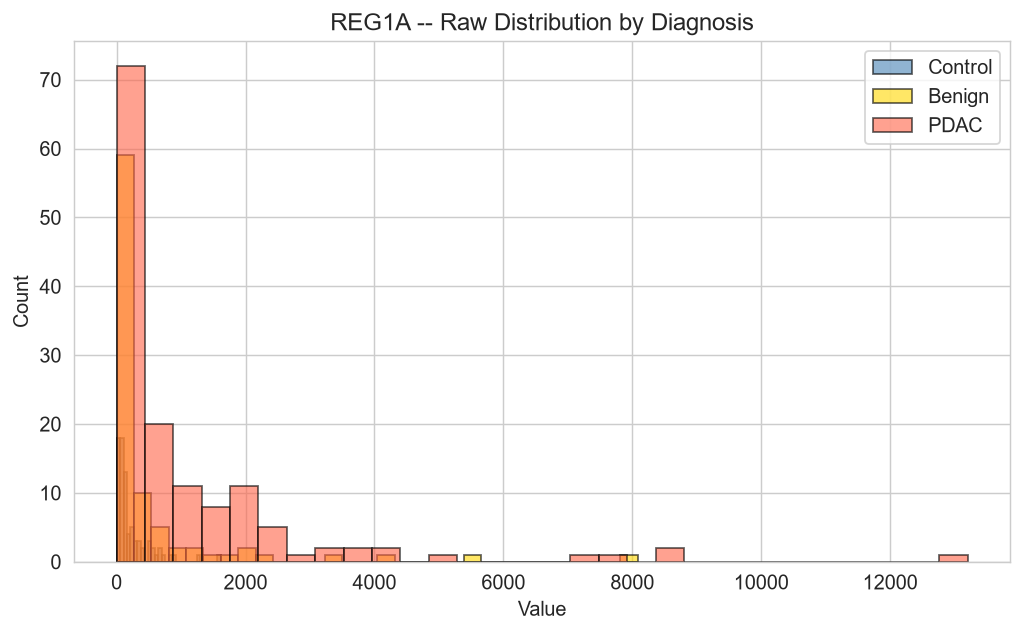

Saved: hist_raw_REG1A.png


In [26]:
plt.figure(figsize=(8, 5))
for cls, subset in zip(['Control', 'Benign', 'PDAC'], values_by_diagnosis(df, 'REG1A')):
    plt.hist(subset, bins=30, alpha=0.6, label=cls, color=DIAG_COLORS[cls], edgecolor='black')
plt.title('REG1A -- Raw Distribution by Diagnosis')
plt.xlabel('Value')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'hist_raw_REG1A.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hist_raw_REG1A.png")

### F2.6. Raw Histogram — `plasma_CA19_9`

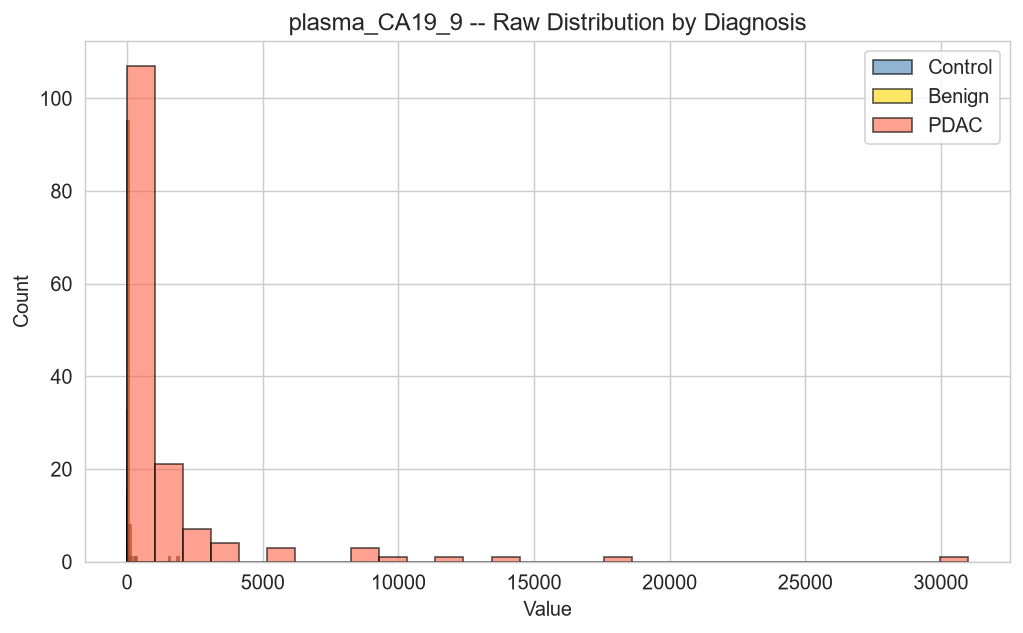

Saved: hist_raw_plasma_CA19_9.png


In [27]:
plt.figure(figsize=(8, 5))
for cls, subset in zip(['Control', 'Benign', 'PDAC'], values_by_diagnosis(df, 'plasma_CA19_9')):
    plt.hist(subset, bins=30, alpha=0.6, label=cls, color=DIAG_COLORS[cls], edgecolor='black')
plt.title('plasma_CA19_9 -- Raw Distribution by Diagnosis')
plt.xlabel('Value')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'hist_raw_plasma_CA19_9.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hist_raw_plasma_CA19_9.png")

### F3.1. Boxplot — `creatinine`

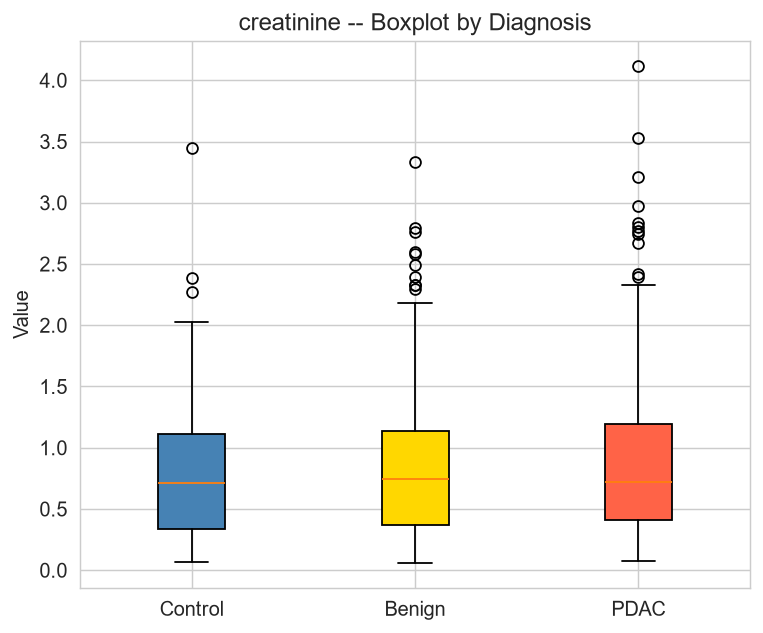

Saved: boxplot_creatinine.png


In [28]:
plt.figure(figsize=(6, 5))
bp_data = values_by_diagnosis(df, 'creatinine')
bp = plt.boxplot(bp_data, patch_artist=True, tick_labels=['Control', 'Benign', 'PDAC'])
for patch, cls in zip(bp['boxes'], ['Control', 'Benign', 'PDAC']):
    patch.set_facecolor(DIAG_COLORS[cls])
plt.title('creatinine -- Boxplot by Diagnosis')
plt.ylabel('Value')
plt.tight_layout()
plt.savefig(OUT_DIR + 'boxplot_creatinine.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: boxplot_creatinine.png")

### F3.2. Boxplot — `LYVE1`

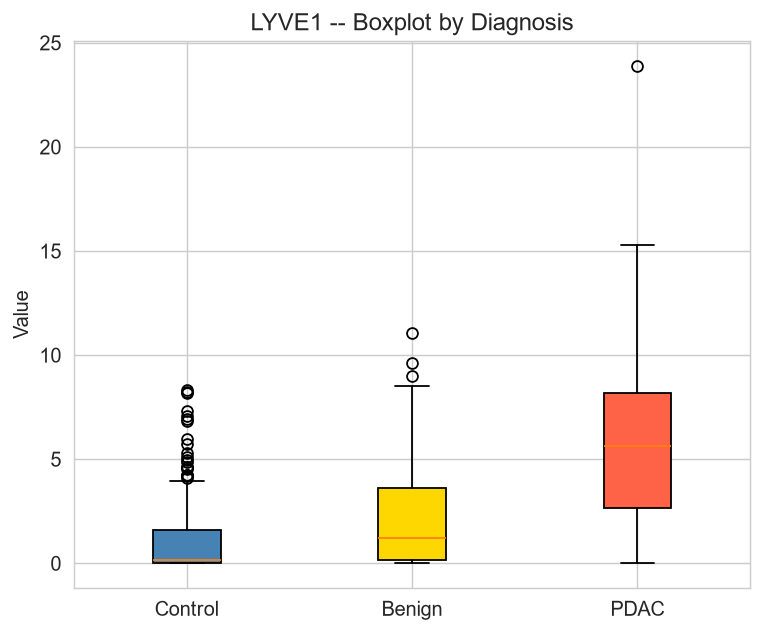

Saved: boxplot_LYVE1.png


In [29]:
plt.figure(figsize=(6, 5))
bp_data = values_by_diagnosis(df, 'LYVE1')
bp = plt.boxplot(bp_data, patch_artist=True, tick_labels=['Control', 'Benign', 'PDAC'])
for patch, cls in zip(bp['boxes'], ['Control', 'Benign', 'PDAC']):
    patch.set_facecolor(DIAG_COLORS[cls])
plt.title('LYVE1 -- Boxplot by Diagnosis')
plt.ylabel('Value')
plt.tight_layout()
plt.savefig(OUT_DIR + 'boxplot_LYVE1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: boxplot_LYVE1.png")

### F3.3. Boxplot — `REG1B`

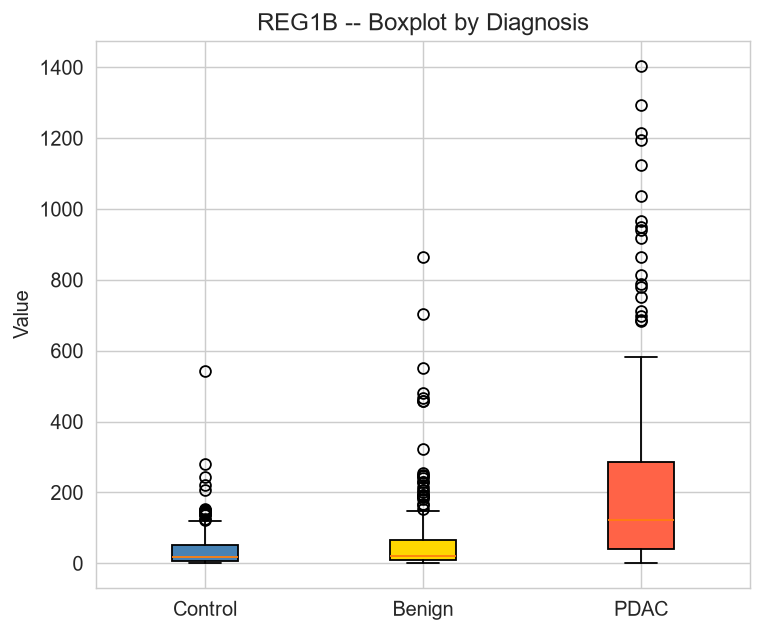

Saved: boxplot_REG1B.png


In [30]:
plt.figure(figsize=(6, 5))
bp_data = values_by_diagnosis(df, 'REG1B')
bp = plt.boxplot(bp_data, patch_artist=True, tick_labels=['Control', 'Benign', 'PDAC'])
for patch, cls in zip(bp['boxes'], ['Control', 'Benign', 'PDAC']):
    patch.set_facecolor(DIAG_COLORS[cls])
plt.title('REG1B -- Boxplot by Diagnosis')
plt.ylabel('Value')
plt.tight_layout()
plt.savefig(OUT_DIR + 'boxplot_REG1B.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: boxplot_REG1B.png")

### F3.4. Boxplot — `TFF1`

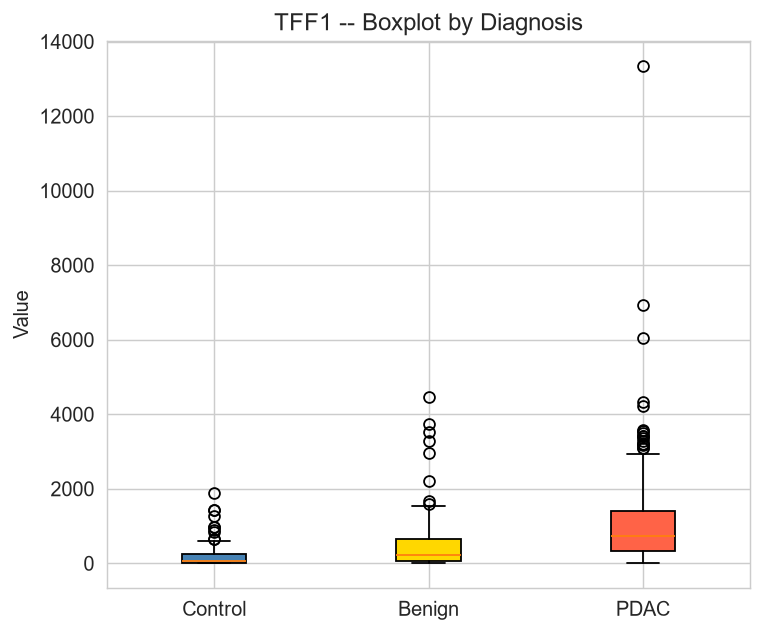

Saved: boxplot_TFF1.png


In [31]:
plt.figure(figsize=(6, 5))
bp_data = values_by_diagnosis(df, 'TFF1')
bp = plt.boxplot(bp_data, patch_artist=True, tick_labels=['Control', 'Benign', 'PDAC'])
for patch, cls in zip(bp['boxes'], ['Control', 'Benign', 'PDAC']):
    patch.set_facecolor(DIAG_COLORS[cls])
plt.title('TFF1 -- Boxplot by Diagnosis')
plt.ylabel('Value')
plt.tight_layout()
plt.savefig(OUT_DIR + 'boxplot_TFF1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: boxplot_TFF1.png")

### F3.5. Boxplot — `REG1A`

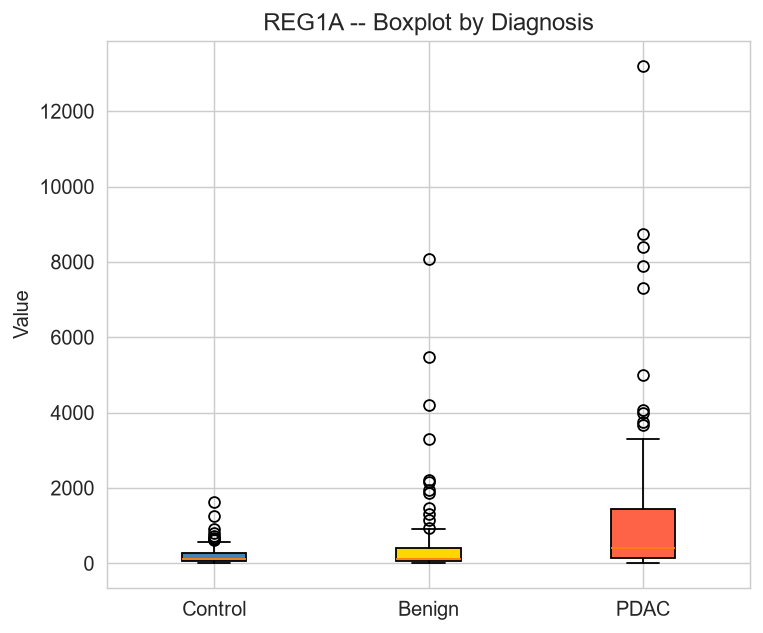

Saved: boxplot_REG1A.png


In [32]:
plt.figure(figsize=(6, 5))
bp_data = values_by_diagnosis(df, 'REG1A')
bp = plt.boxplot(bp_data, patch_artist=True, tick_labels=['Control', 'Benign', 'PDAC'])
for patch, cls in zip(bp['boxes'], ['Control', 'Benign', 'PDAC']):
    patch.set_facecolor(DIAG_COLORS[cls])
plt.title('REG1A -- Boxplot by Diagnosis')
plt.ylabel('Value')
plt.tight_layout()
plt.savefig(OUT_DIR + 'boxplot_REG1A.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: boxplot_REG1A.png")

### F3.6. Boxplot — `plasma_CA19_9`

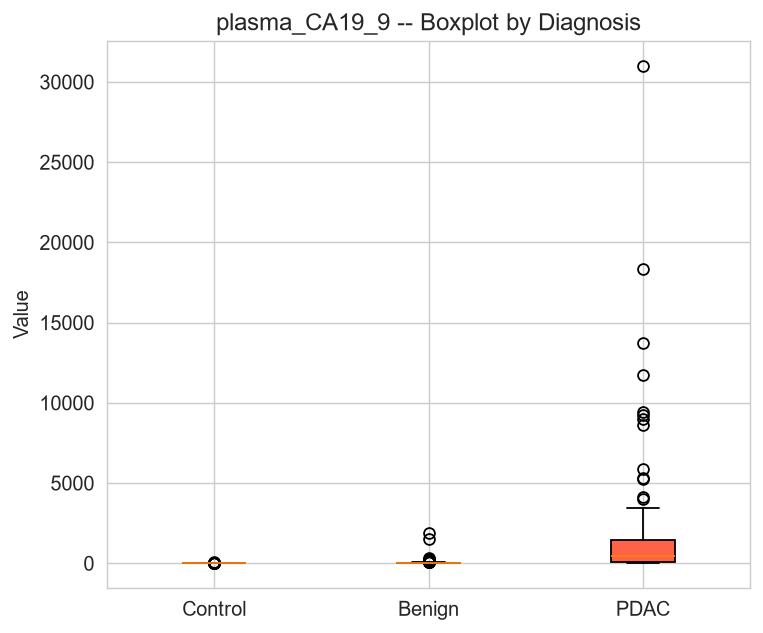

Saved: boxplot_plasma_CA19_9.png


In [33]:
plt.figure(figsize=(6, 5))
bp_data = values_by_diagnosis(df, 'plasma_CA19_9')
bp = plt.boxplot(bp_data, patch_artist=True, tick_labels=['Control', 'Benign', 'PDAC'])
for patch, cls in zip(bp['boxes'], ['Control', 'Benign', 'PDAC']):
    patch.set_facecolor(DIAG_COLORS[cls])
plt.title('plasma_CA19_9 -- Boxplot by Diagnosis')
plt.ylabel('Value')
plt.tight_layout()
plt.savefig(OUT_DIR + 'boxplot_plasma_CA19_9.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: boxplot_plasma_CA19_9.png")

## Section G — Outlier Quantification (IQR)

The original notebook's boxplots show outliers visually but never computed IQR bounds or counts. This section computes Q1, Q3, IQR, and the count/percentage of values outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` for every biomarker, split by diagnosis class. **Purely descriptive** — nothing here is removed or capped; these are documented as real, expected biological extremes.

### G1. IQR Outlier Counts Per Biomarker, Per Diagnosis Class

In [34]:
biomarker_cols = ['creatinine', 'LYVE1', 'REG1B', 'TFF1', 'REG1A', 'plasma_CA19_9']
outlier_rows = []
for bm in biomarker_cols:
    for cls, values in zip(['Control', 'Benign', 'PDAC'], values_by_diagnosis(df, bm)):
        if len(values) == 0:
            continue
        q1, q3 = np.percentile(values, [25, 75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_outliers = int(((values < lower) | (values > upper)).sum())
        outlier_rows.append({
            'biomarker': bm, 'diagnosis': cls,
            'Q1': round(q1, 2), 'Q3': round(q3, 2), 'IQR': round(iqr, 2),
            'lower_bound': round(lower, 2), 'upper_bound': round(upper, 2),
            'n': len(values), 'n_outliers': n_outliers,
            'pct_outliers': round(100 * n_outliers / len(values), 1),
        })

outlier_df = pd.DataFrame(outlier_rows)

print("=" * 55)
print("  IQR OUTLIER QUANTIFICATION (per biomarker, per diagnosis class)")
print("=" * 55)
print(outlier_df.to_string(index=False))

  IQR OUTLIER QUANTIFICATION (per biomarker, per diagnosis class)
    biomarker diagnosis     Q1      Q3     IQR  lower_bound  upper_bound   n  n_outliers  pct_outliers
   creatinine   Control   0.33    1.11    0.77        -0.83         2.27 183           3           1.6
   creatinine    Benign   0.37    1.14    0.77        -0.78         2.29 208          10           4.8
   creatinine      PDAC   0.41    1.19    0.79        -0.77         2.37 199          11           5.5
        LYVE1   Control   0.00    1.60    1.60        -2.39         4.00 183          20          10.9
        LYVE1    Benign   0.16    3.64    3.47        -5.05         8.85 208           3           1.4
        LYVE1      PDAC   2.68    8.19    5.52        -5.60        16.47 199           1           0.5
        REG1B   Control   6.32   51.87   45.55       -62.00       120.19 183          17           9.3
        REG1B    Benign   8.02   65.00   56.99       -77.46       150.48 208          26          12.5
       

## Section H — CA19-9 Clinical Deep Dive

### H1. Cutoff Analysis at 37 U/ml

Log-transformed panel removed per this notebook's no-transform policy — raw boxplot and the clinical-threshold bar chart only.

  CA19-9 ANALYSIS
                 count     mean      std  min    25%     50%      75%      max
diagnosis_label                                                               
Benign           108.0    61.79   235.82  1.0   9.75   17.00    29.25   1913.0
Control           92.0     8.75    12.19  0.0   1.71    5.33     9.15     84.3
PDAC             150.0  1476.15  3550.04  0.6  99.70  427.50  1457.50  31000.0

  Missing CA19-9 per class:
    Control   : 91/183 missing (49.7%)
    Benign    : 100/208 missing (48.1%)
    PDAC      : 49/199 missing (24.6%)


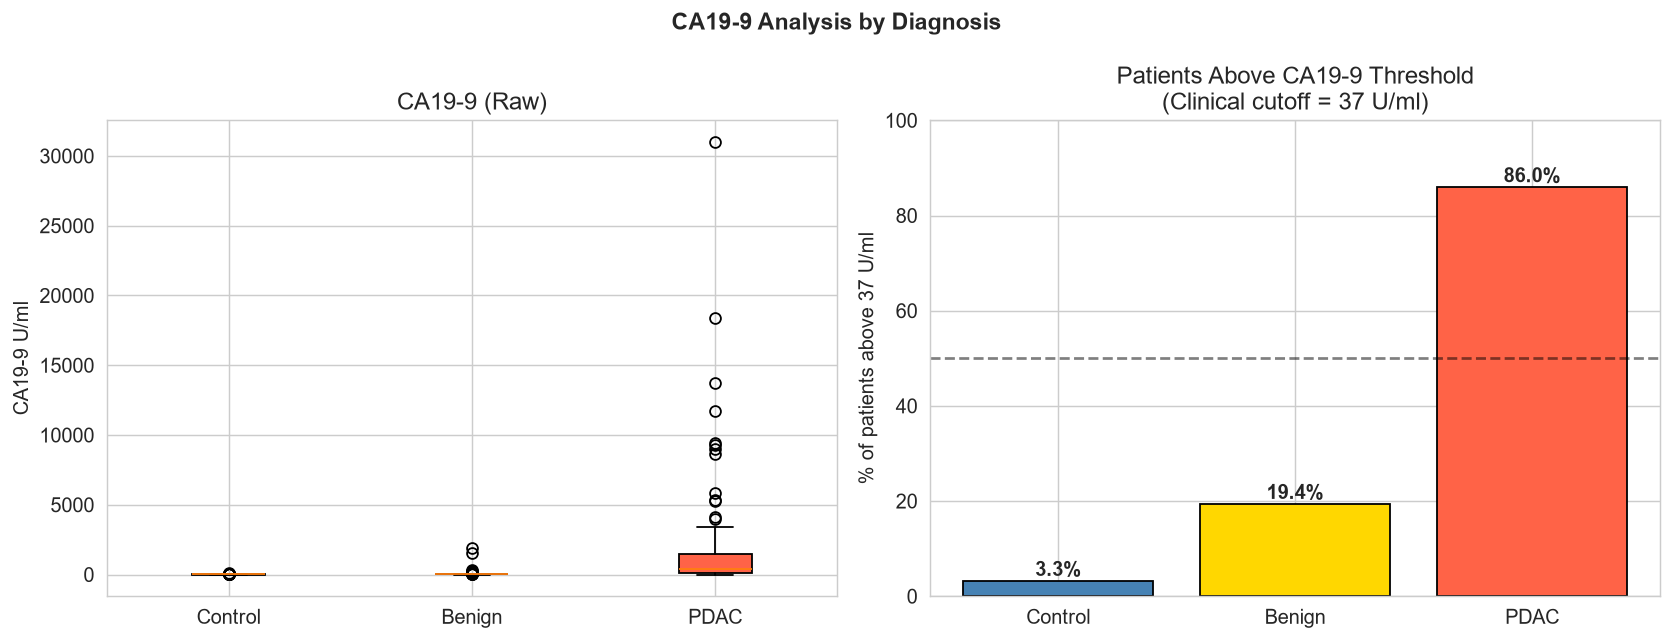

✅ Saved: ca19_9_analysis.png


In [35]:
# ── CA19-9 analysis (blood marker) ───────────────────
print("=" * 55)
print("  CA19-9 ANALYSIS")
print("=" * 55)

ca_stats = df.groupby('diagnosis_label')[
    'plasma_CA19_9'
].describe().round(2)
print(ca_stats.to_string())

ca_missing = df.groupby('diagnosis_label')[
    'plasma_CA19_9'
].apply(lambda x: x.isnull().sum())
print(f"\n  Missing CA19-9 per class:")
for cls in ['Control', 'Benign', 'PDAC']:
    total = len(df[df['diagnosis_label'] == cls])
    miss  = ca_missing[cls]
    print(f"    {cls:10s}: "
          f"{miss}/{total} missing "
          f"({100*miss/total:.1f}%)")

# ── Plot -- log-transformed panel removed (no-transform policy) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'CA19-9 Analysis by Diagnosis',
    fontsize=13, fontweight='bold'
)

# Raw boxplot
bp_data = [
    df[df['diagnosis_label'] == cls][
        'plasma_CA19_9'
    ].dropna().values
    for cls in ['Control', 'Benign', 'PDAC']
]
bp = axes[0].boxplot(
    bp_data,
    patch_artist=True,
    tick_labels=['Control', 'Benign', 'PDAC']
)
for patch, cls in zip(
    bp['boxes'],
    ['Control', 'Benign', 'PDAC']
):
    patch.set_facecolor(DIAG_COLORS[cls])
axes[0].set_title('CA19-9 (Raw)')
axes[0].set_ylabel('CA19-9 U/ml')

# Threshold bar chart at 37 U/ml (clinical cutoff)
for cls in ['Control', 'Benign', 'PDAC']:
    subset = df[
        df['diagnosis_label'] == cls
    ]['plasma_CA19_9'].dropna()
    above = (subset > 37).sum()
    pct   = above / len(subset) * 100
    axes[1].bar(
        cls,
        pct,
        color=DIAG_COLORS[cls],
        edgecolor='black'
    )
    axes[1].text(
        cls, pct + 1,
        f'{pct:.1f}%',
        ha='center',
        fontweight='bold'
    )
axes[1].axhline(
    y=50, color='black',
    linestyle='--', alpha=0.5
)
axes[1].set_title(
    'Patients Above CA19-9 Threshold\n'
    '(Clinical cutoff = 37 U/ml)'
)
axes[1].set_ylabel('% of patients above 37 U/ml')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(
    OUT_DIR + 'ca19_9_analysis.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Saved: ca19_9_analysis.png")

## Section I — Correlation & Statistical Testing

### I1. Pearson Correlation Heatmap & Ranked Bar Chart

  CORRELATION MATRIX
                age  plasma_CA19_9  creatinine  LYVE1  REG1B  TFF1  REG1A  diagnosis
age            1.00           0.14       -0.07   0.33   0.20  0.21   0.06       0.31
plasma_CA19_9  0.14           1.00       -0.03   0.26   0.18  0.15   0.12       0.26
creatinine    -0.07          -0.03        1.00   0.34   0.26  0.40   0.06       0.07
LYVE1          0.33           0.26        0.34   1.00   0.54  0.58   0.28       0.54
REG1B          0.20           0.18        0.26   0.54   1.00  0.69   0.56       0.38
TFF1           0.21           0.15        0.40   0.58   0.69  1.00   0.42       0.39
REG1A          0.06           0.12        0.06   0.28   0.56  0.42   1.00       0.26
diagnosis      0.31           0.26        0.07   0.54   0.38  0.39   0.26       1.00

───────────────────────────────────────────────────────
  TOP CORRELATIONS WITH DIAGNOSIS
───────────────────────────────────────────────────────
LYVE1            0.54
TFF1             0.39
REG1B            0.38
a

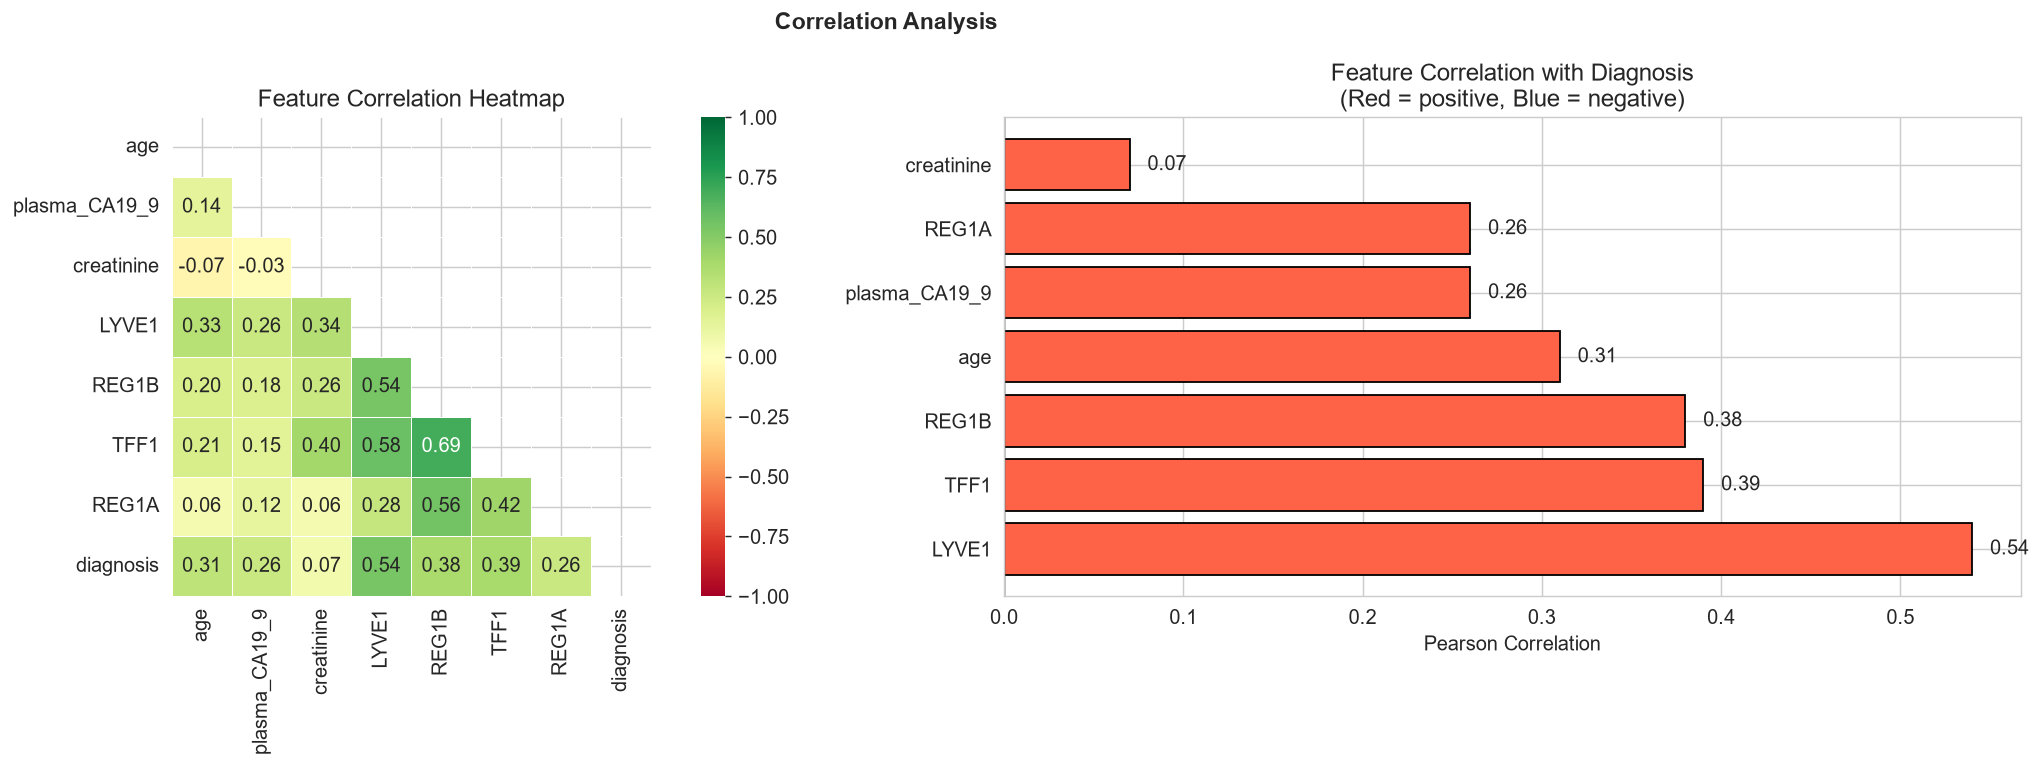

✅ Saved: correlation_heatmap.png


In [36]:
numeric_cols = [
    'age', 'plasma_CA19_9', 'creatinine',
    'LYVE1', 'REG1B', 'TFF1', 'REG1A',
    'diagnosis'
]

corr_matrix = df[numeric_cols].corr().round(2)

print("=" * 55)
print("  CORRELATION MATRIX")
print("=" * 55)
print(corr_matrix.to_string())

print(f"\n{'─'*55}")
print("  TOP CORRELATIONS WITH DIAGNOSIS")
print(f"{'─'*55}")
diag_corr = corr_matrix['diagnosis'].drop('diagnosis').sort_values(ascending=False)
print(diag_corr.to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Correlation Analysis', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, ax=axes[0], mask=mask,
    square=True, linewidths=0.5
)
axes[0].set_title('Feature Correlation Heatmap')

colors_corr = ['tomato' if v > 0 else 'steelblue' for v in diag_corr.values]
axes[1].barh(diag_corr.index, diag_corr.values, color=colors_corr, edgecolor='black')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Diagnosis\n(Red = positive, Blue = negative)')
axes[1].set_xlabel('Pearson Correlation')
for i, v in enumerate(diag_corr.values):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.2f}', va='center',
                 ha='left' if v >= 0 else 'right')

plt.tight_layout()
plt.savefig(OUT_DIR + 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\u2705 Saved: correlation_heatmap.png")

### I2. Kruskal-Wallis H-Test

Non-parametric alternative to ANOVA — doesn't assume normally distributed groups, appropriate given Section F confirms these biomarkers are far from normal. Pearson above assumes a linear relationship these biomarkers don't have.

In [37]:
kruskal_rows = []
for col in ['age', 'plasma_CA19_9', 'creatinine', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']:
    groups = values_by_diagnosis(df, col)
    stat, p = kruskal(*groups)
    kruskal_rows.append({'feature': col, 'H_statistic': round(stat, 2), 'p_value': p})
kruskal_df = pd.DataFrame(kruskal_rows).sort_values('H_statistic', ascending=False)

print("=" * 55)
print("  KRUSKAL-WALLIS H-TEST (biomarker vs diagnosis group)")
print("=" * 55)
print(kruskal_df.to_string(index=False))

  KRUSKAL-WALLIS H-TEST (biomarker vs diagnosis group)
      feature  H_statistic      p_value
plasma_CA19_9       209.01 4.118463e-46
        LYVE1       208.88 4.385364e-46
         TFF1       161.86 7.110252e-36
        REG1B       133.21 1.183477e-29
          age        92.11 9.973709e-21
        REG1A        44.25 2.462175e-10
   creatinine         1.11 5.735071e-01


## Section J — PDAC Stage Analysis

### J1. Stage Distribution & Median Biomarkers by Stage

  CANCER STAGE ANALYSIS (PDAC only)

  Stage distribution:
stage
III    76
IIB    68
IV     21
IB     12
IIA    11
II      7
IA      3
I       1

  Missing stage: 0

───────────────────────────────────────────────────────
  MEDIAN BIOMARKER BY STAGE
───────────────────────────────────────────────────────
       LYVE1   REG1B     TFF1  plasma_CA19_9
stage                                       
I      12.02  431.42   874.10            NaN
IA      2.63   40.62   323.18           11.0
IB      1.85   49.34   424.07          155.3
II     10.25  279.52  1063.95            NaN
IIA     1.81  144.48   736.67          328.0
IIB     5.49  123.14   685.67          267.0
III     5.80  105.34   693.08          553.0
IV      7.86  156.24   903.13          941.0


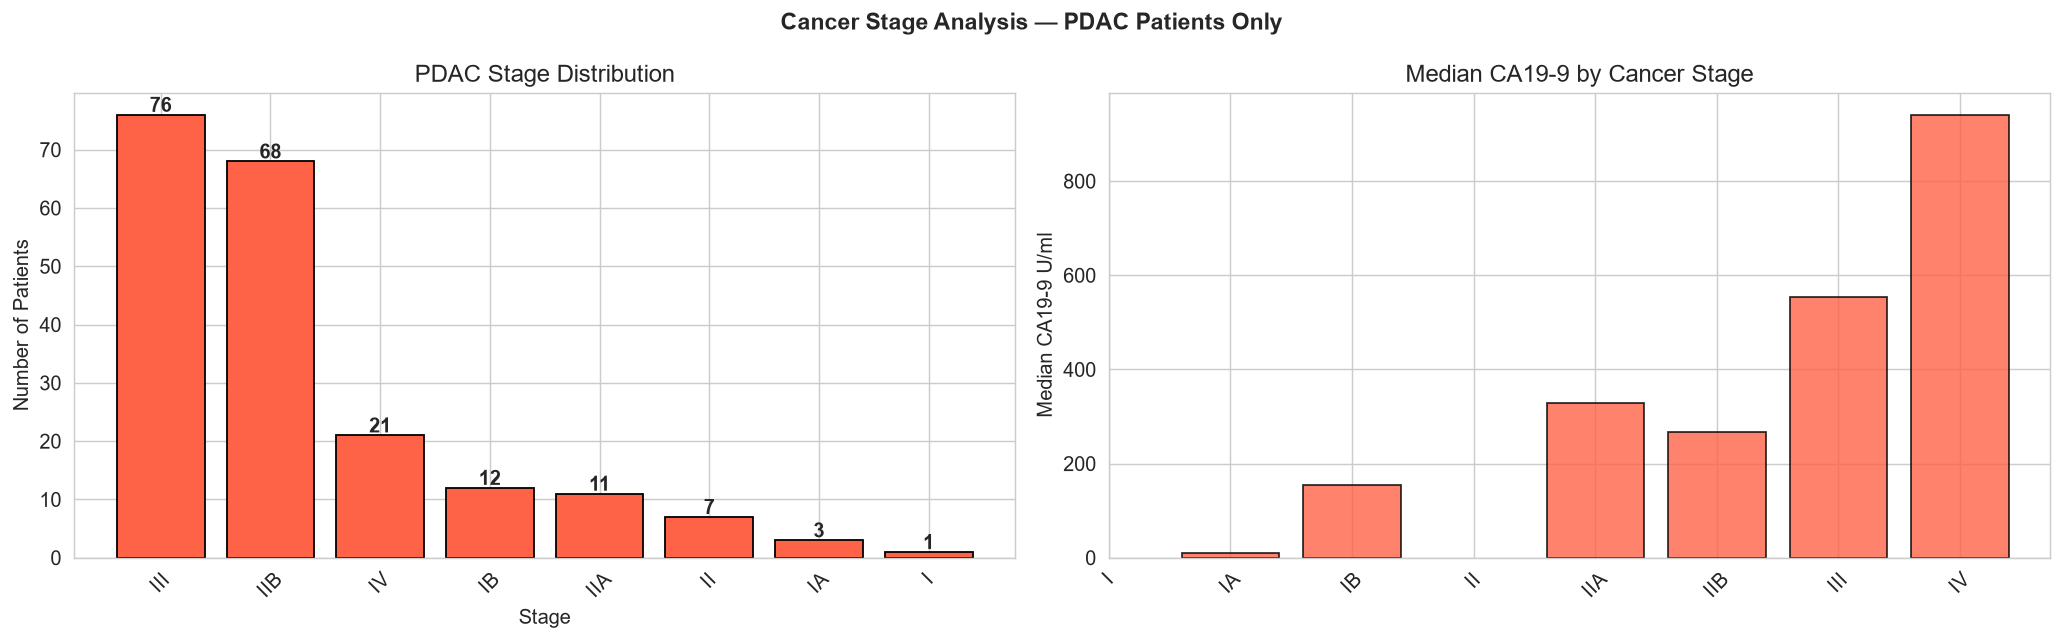

✅ Saved: stage_analysis.png


In [38]:
# ── Cancer stage analysis (PDAC only) ────────────────
pdac_df = df[df['diagnosis'] == 3].copy()

print("=" * 55)
print("  CANCER STAGE ANALYSIS (PDAC only)")
print("=" * 55)
stage_counts = pdac_df['stage'].value_counts()
print(f"\n  Stage distribution:")
print(stage_counts.to_string())
print(f"\n  Missing stage: "
      f"{pdac_df['stage'].isnull().sum()}")

# ── Biomarker by stage ────────────────────────────────
print(f"\n{'─'*55}")
print("  MEDIAN BIOMARKER BY STAGE")
print(f"{'─'*55}")
stage_order = ['I', 'IA', 'IB',
               'II', 'IIA', 'IIB',
               'III', 'IV']
existing_stages = [
    s for s in stage_order
    if s in pdac_df['stage'].values
]
stage_bm = pdac_df.groupby('stage')[
    ['LYVE1', 'REG1B', 'TFF1',
     'plasma_CA19_9']
].median().round(2)
print(stage_bm.to_string())

# ── Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    'Cancer Stage Analysis — PDAC Patients Only',
    fontsize=13, fontweight='bold'
)

# Stage distribution
stage_counts_plot = pdac_df[
    'stage'
].value_counts()
axes[0].bar(
    stage_counts_plot.index,
    stage_counts_plot.values,
    color='tomato',
    edgecolor='black'
)
axes[0].set_title('PDAC Stage Distribution')
axes[0].set_xlabel('Stage')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=45)
for i, (s, v) in enumerate(
    stage_counts_plot.items()
):
    axes[0].text(
        i, v + 0.5,
        str(v),
        ha='center',
        fontweight='bold'
    )

# CA19-9 by stage
stage_ca = pdac_df.groupby('stage')[
    'plasma_CA19_9'
].median().reindex(existing_stages)
axes[1].bar(
    range(len(stage_ca)),
    stage_ca.values,
    color='tomato',
    edgecolor='black',
    alpha=0.8
)
axes[1].set_xticks(range(len(stage_ca)))
axes[1].set_xticklabels(
    stage_ca.index, rotation=45
)
axes[1].set_title(
    'Median CA19-9 by Cancer Stage'
)
axes[1].set_ylabel('Median CA19-9 U/ml')

plt.tight_layout()
plt.savefig(
    OUT_DIR + 'stage_analysis.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Saved: stage_analysis.png")

## Section K — EDA Summary

### K1. Findings Summary

In [39]:
print("=" * 55)
print("  EDA COMPLETE -- FINDINGS SUMMARY")
print("=" * 55)

print(f"""
  Dataset:
    Total patients:    {len(df)}
    Features:          {df.shape[1] - 1}
    Target classes:    3
      Control (1):  {(df.diagnosis==1).sum()}
      Benign  (2):  {(df.diagnosis==2).sum()}
      PDAC    (3):  {(df.diagnosis==3).sum()}
""")

print(f"{'─'*55}")
print("  Missing Values (see Sections C, D)")
print(f"{'─'*55}")
print(f"  plasma_CA19_9: {(df.plasma_CA19_9.isnull().sum())} missing -- "
      f"documented: assessed in only 350/590 patients (study design)")
print(f"  REG1A:         {(df.REG1A.isnull().sum())} missing -- "
      f"documented: assessed in only 306/590 patients (study design), "
      f"concentrated almost entirely in Cohort2 (258/258 missing there -- see D4)")
print(f"  stage, benign_sample_diagnosis: missing by design, 100% structural "
      f"-- given explicit sentinel categories ('No Cancer' / 'Control/PDAC') "
      f"in D2 rather than imputed, since \"not applicable\" isn't a value "
      f"that can be estimated")
print(f"  All other columns: 0 missing")

print(f"\n{'─'*55}")
print("  Skewness -- all 6 biomarkers (Section F1)")
print(f"{'─'*55}")
print(skew_table.to_string())

print(f"\n{'─'*55}")
print("  IQR Outlier Summary, total outliers per biomarker across all classes (Section G1)")
print(f"{'─'*55}")
outlier_summary = outlier_df.groupby('biomarker')['n_outliers'].sum().sort_values(ascending=False)
print(outlier_summary.to_string())

print(f"\n{'─'*55}")
print("  Strongest predictors of PDAC -- Pearson |r| and Kruskal-Wallis H side by side (Section I)")
print(f"{'─'*55}")
diag_corr_full = df[['LYVE1', 'REG1B', 'TFF1', 'REG1A', 'plasma_CA19_9',
                      'creatinine', 'age', 'diagnosis']].corr()['diagnosis'].drop('diagnosis')
combined = diag_corr_full.abs().sort_values(ascending=False).to_frame('pearson_abs_r').join(
    kruskal_df.set_index('feature')[['H_statistic', 'p_value']]
)
print(combined.to_string())

print(f"""
  IMPORTANT -- skewness and outliers above are DOCUMENTED, NOT TRANSFORMED:
    These biomarkers are lab test results. High skew and IQR-flagged
    "outliers" reflect genuine, expected biological variation (e.g. a PDAC
    patient with a very high CA19-9 reading is not a data error) -- no log
    transform, winsorizing, or outlier removal was applied anywhere in
    this notebook. Any modeling decision to transform or cap values is a
    downstream, separate decision -- not made here.

  Preprocessing requirements identified:
    1. Impute plasma_CA19_9 / REG1A -- missing-by-design (study coverage),
       not random; REG1A's near-total absence in Cohort2 means a single
       global imputation statistic is the wrong approach.
    2. stage / benign_sample_diagnosis already carry explicit sentinel
       categories (Section D2) -- no further imputation needed there.
    3. Decide on outlier handling for modeling purposes using the IQR
       table (Section G1) as reference -- this EDA does not decide that.
    4. Encode categorical variables (sex, cohort, origin, stage,
       benign_sample_diagnosis).
    5. Normalise all numeric features (scaling, not log-transforming).
    6. Handle class imbalance if needed.
    7. Resolve the stage-code discrepancy against the data dictionary
       (Section C2) before using `stage` downstream.

\u2705 Ready for preprocessing pipeline
""")

  EDA COMPLETE -- FINDINGS SUMMARY

  Dataset:
    Total patients:    590
    Features:          14
    Target classes:    3
      Control (1):  183
      Benign  (2):  208
      PDAC    (3):  199

───────────────────────────────────────────────────────
  Missing Values (see Sections C, D)
───────────────────────────────────────────────────────
  plasma_CA19_9: 240 missing -- documented: assessed in only 350/590 patients (study design)
  REG1A:         284 missing -- documented: assessed in only 306/590 patients (study design), concentrated almost entirely in Cohort2 (258/258 missing there -- see D4)
  stage, benign_sample_diagnosis: missing by design, 100% structural -- given explicit sentinel categories ('No Cancer' / 'Control/PDAC') in D2 rather than imputed, since "not applicable" isn't a value that can be estimated
  All other columns: 0 missing

───────────────────────────────────────────────────────
  Skewness -- all 6 biomarkers (Section F1)
────────────────────────────────────